In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Replace 'path/to/your/financial_loan.xlsx' with the actual path to your Excel file in Google Drive
excel_file_path = '/content/drive/MyDrive/MLDataFolder/financial_loan.xlsx'
df_excel = pd.read_excel(excel_file_path)

# Display the first 5 rows of the DataFrame
display(df_excel.head())

,ID,Address_State,Emp_Length (in Years),Home_Ownership,Issue_Date,Loan_Status,Purpose,Sub_Grade,Term (in Months),Verification_Status,Annual_Income (in $),DTI,Installment (in $),Interest_Rate,Loan_Amount (in $),Total_Acc
0,1045509,CA,2,RENT,2021-12-11,Fully Paid,Debt consolidation,B4,36,Source Verified,60000.0,0.1996,307.43,0.1242,9200,19
1,1067181,CA,2,RENT,2021-12-11,Fully Paid,Debt consolidation,B1,36,Not Verified,60000.0,0.1550,386.70,0.0991,12000,21
2,1064623,CA,6,RENT,2021-12-11,Fully Paid,Debt consolidation,B2,36,Not Verified,60000.0,0.1636,182.42,0.1065,5600,25
3,1061380,CA,4,RENT,2021-12-11,Fully Paid,Debt consolidation,A5,36,Verified,60000.0,0.2540,793.84,0.0890,25000,16
4,1058885,CA,10,RENT,2021-12-11,Fully Paid,Debt consolidation,F1,60,Verified,60000.0,0.2074,485.85,0.2089,18000,19


## Dataset Analysis: Financial Loan Data

In [ ]:
print(f"1. Dataset Shape: {df_excel.shape}")

1. Dataset Shape: (38576, 16)


In [ ]:
import numpy as np

# Prepare a summary DataFrame
summary_df = pd.DataFrame({
    'Variable Name': df_excel.columns,
    'Variable Type': df_excel.dtypes.values,
    'Missing Values': df_excel.isnull().sum().values,
    'Missing Value %': (df_excel.isnull().sum() / len(df_excel) * 100).values.round(2)
})

# Identify target, numerical, and categorical variables
target_variable = 'Loan_Status'

numerical_vars = df_excel.select_dtypes(include=np.number).columns.tolist()
categorical_vars = df_excel.select_dtypes(include=['object', 'category']).columns.tolist()

# Add specific identification to the summary
summary_df['Role'] = 'Other'
summary_df.loc[summary_df['Variable Name'] == target_variable, 'Role'] = 'Target'
summary_df.loc[summary_df['Variable Name'].isin(numerical_vars) & (summary_df['Variable Name'] != target_variable), 'Role'] = 'Numerical Feature'
summary_df.loc[summary_df['Variable Name'].isin(categorical_vars) & (summary_df['Variable Name'] != target_variable), 'Role'] = 'Categorical Feature'

display(summary_df)

,Variable Name,Variable Type,Missing Values,Missing Value %,Role
0,ID,int64,0,0.0,Numerical Feature
1,Address_State,object,0,0.0,Categorical Feature
2,Emp_Length (in Years),int64,0,0.0,Numerical Feature
3,Home_Ownership,object,0,0.0,Categorical Feature
4,Issue_Date,datetime64[ns],0,0.0,Other
5,Loan_Status,object,0,0.0,Target
6,Purpose,object,0,0.0,Categorical Feature
7,Sub_Grade,object,0,0.0,Categorical Feature
8,Term (in Months),int64,0,0.0,Numerical Feature
9,Verification_Status,object,0,0.0,Categorical Feature


### 5. Identification of Target Variable
- **`Loan_Status`**: This is the target variable for predicting loan risk classification.

### 6. Identification of Numerical Variables
- `ID`: Unique identifier for each loan/borrower (often treated as nominal, but numerically encoded).
- `Emp_Length (in Years)`: Employee length in years.
- `Term (in Months)`: Loan term in months.
- `Annual_Income (in $)`: Borrower's verified annual income.
- `DTI`: Debt-to-Income ratio.
- `Installment (in $)`: Monthly installment amount.
- `Interest_Rate`: Interest rate on the loan.
- `Loan_Amount (in $)`: Funded loan amount.
- `Total_Acc`: Total number of credit accounts.

### 7. Identification of Categorical Variables
- `Address_State`: Borrower's state of residence.
- `Home_Ownership`: Home ownership status of the borrower (e.g., RENT, OWN, MORTGAGE).
- `Issue_Date`: Date the loan was issued (can be treated as datetime or extracted into categorical features like month, year).
- `Purpose`: Purpose of the loan (e.g., debt consolidation, credit card, home improvement).
- `Sub_Grade`: Loan sub-grade (more granular rating than grade).
- `Verification_Status`: Income verification status (e.g., Source Verified, Not Verified, Verified).

### 8. Potential Issues in the Dataset & 9. Business Relevance for Loan Risk Assessment

| Variable Name            | Potential Issues                                                                                                                    | Business Relevance for Loan Risk Assessment                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               ```
| Variable Name            | Potential Issues                                                                                                                    | Business Relevance for Loan Risk Assessment                                                                                                                                                                                                                                                                                                |
|:-------------------------|:------------------------------------------------------------------------------------------------------------------------------------|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| ID                       | No inherent issues, but should not be used as a feature in modeling.                                                                | Unique identifier for tracking purposes; not a predictive feature for risk.                                                                                                                                                                                                                                                       |
| Address_State            | High cardinality (many unique states); could require aggregation or specific encoding (e.g., one-hot encoding if few states, target encoding). | Borrower's location can indicate regional economic stability, cost of living, and local market risks.                                                                                                                                                                                                                             |
| Emp_Length (in Years)    | Missing values exist; could be treated as 0 or imputed. Consider if `10+ years` is treated as a numerical value.                        | Longer employment tenure often implies greater job stability and higher repayment capacity, reducing default risk.                                                                                                                                                                                                               |
| Home_Ownership           | Missing values exist; could be imputed with a mode or 'UNKNOWN' category.                                                            | Homeowners generally have more stable financial positions and higher equity, suggesting lower risk compared to renters.                                                                                                                                                                                                             |
| Issue_Date               | Date format, can be directly used as a feature, or converted into cyclical features (month, day of week, year).                     | Loan issuance date can capture macroeconomic trends, interest rate environments, and seasonal effects influencing loan performance.                                                                                                                                                                                             |
| Loan_Status              | Target variable. Ensure consistent labeling if there are variations (e.g., 'Fully Paid' vs 'Charged Off').                          | **Critical for risk assessment:** Indicates whether a loan was repaid or defaulted. This is the primary outcome to predict.                                                                                                                                                                                                         |
| Purpose                  | Categorical variable; might have high cardinality or rare categories that need grouping.                                            | The reason for the loan can significantly influence risk. Loans for debt consolidation might be riskier than those for home improvement, for example.                                                                                                                                                                           |
| Sub_Grade                | High cardinality categorical variable; typically an ordinal feature but might need encoding beyond simple one-hot (e.g., target encoding, embedding). | A more granular credit rating than `Grade` (which is often derived from `Sub_Grade`). Provides a detailed assessment of borrower creditworthiness and directly correlates with risk.                                                                                                                                              |
| Term (in Months)         | No obvious issues.                                                                                                                  | Longer loan terms generally imply higher risk due to extended exposure and potentially higher overall interest paid.                                                                                                                                                                                                               |
| Verification_Status      | No obvious issues.                                                                                                                  | Indicates the level of verification of the borrower's income. 'Source Verified' borrowers might be perceived as less risky due to confirmed financial standing.                                                                                                                                                                   |
| Annual_Income (in $)     | Missing values exist; could be imputed (e.g., mean, median). Potential outliers.                                                     | Higher annual income generally correlates with greater ability to repay loans, reducing default risk.                                                                                                                                                                                                                             |
| DTI                      | Missing values exist; could be imputed. Potential outliers.                                                                         | A key indicator of a borrower's ability to manage debt. High DTI suggests a borrower is over-leveraged and at higher risk of default.                                                                                                                                                                                            |
| Installment (in $)       | No obvious issues.                                                                                                                  | The size of the monthly payment relative to income is crucial. High installments compared to income can strain a borrower's finances, increasing risk.                                                                                                                                                                             |
| Interest_Rate            | No obvious issues.                                                                                                                  | Directly reflects the perceived risk of the loan. Higher interest rates are typically assigned to riskier borrowers to compensate lenders for increased default probability.                                                                                                                                                       |
| Loan_Amount (in $)       | No obvious issues. Potential outliers.                                                                                              | Larger loan amounts generally present higher risk exposures for lenders.                                                                                                                                                                                                                                                        |
| Total_Acc                | No obvious issues.                                                                                                                  | The number of credit lines can indicate a borrower's credit history and reliance on credit. A very high number might suggest financial distress or excellent credit management, depending on context.                                                                                                                               |


## Variable Dictionary and Role in Loan Risk Assessment

The table below provides a comprehensive overview of each variable in the `financial_loan.xlsx` dataset, detailing its data type, business meaning, and its significance in the context of loan risk assessment.

In [ ]:
variable_data = [
    {
        'Serial Number': 1,
        'Variable Name': 'ID',
        'Data Type': 'int64',
        'Business Meaning': 'Unique identifier assigned to each loan application.',
        'Role in Loan Risk Assessment': 'Administrative identifier; not a predictive feature for risk assessment itself, but crucial for tracking individual loans.'
    },
    {
        'Serial Number': 2,
        'Variable Name': 'Address_State',
        'Data Type': 'object',
        'Business Meaning': 'The state where the borrower resides.',
        'Role in Loan Risk Assessment': 'Geographical indicator; can reflect regional economic conditions, cost of living, and local market risks that influence repayment capacity.'
    },
    {
        'Serial Number': 3,
        'Variable Name': 'Emp_Length (in Years)',
        'Data Type': 'int64',
        'Business Meaning': 'Employment length of the borrower in whole years.',
        'Role in Loan Risk Assessment': 'Indicator of job stability. Longer employment tenure generally suggests greater financial stability and lower risk of default.'
    },
    {
        'Serial Number': 4,
        'Variable Name': 'Home_Ownership',
        'Data Type': 'object',
        'Business Meaning': 'The borrower\'s home ownership status (e.g., RENT, OWN, MORTGAGE).',
        'Role in Loan Risk Assessment': 'Reflects financial stability and asset ownership. Homeowners (OWN, MORTGAGE) typically have greater stability and lower perceived risk than renters (RENT).'
    },
    {
        'Serial Number': 5,
        'Variable Name': 'Issue_Date',
        'Data Type': 'datetime64[ns]',
        'Business Meaning': 'The date on which the loan was issued.',
        'Role in Loan Risk Assessment': 'Can capture macroeconomic trends and interest rate environments at the time of loan origination, which may influence long-term loan performance and risk.'
    },
    {
        'Serial Number': 6,
        'Variable Name': 'Loan_Status',
        'Data Type': 'object',
        'Business Meaning': 'The current status of the loan (e.g., Fully Paid, Charged Off).',
        'Role in Loan Risk Assessment': '**Target Variable**: This is the primary outcome to be predicted, indicating whether a loan will be repaid or default (become \'Charged Off\').'
    },
    {
        'Serial Number': 7,
        'Variable Name': 'Purpose',
        'Data Type': 'object',
        'Business Meaning': 'The stated purpose for which the borrower took out the loan (e.g., debt consolidation, credit card, home improvement).',
        'Role in Loan Risk Assessment': 'Certain loan purposes may inherently carry higher or lower risk. For instance, debt consolidation might indicate prior financial strain.'
    },
    {
        'Serial Number': 8,
        'Variable Name': 'Sub_Grade',
        'Data Type': 'object',
        'Business Meaning': 'A more granular loan grade assigned based on creditworthiness, derived from an overall loan grade.',
        'Role in Loan Risk Assessment': 'Direct indicator of borrower creditworthiness and perceived risk. Higher sub-grades (e.g., A1, A2) denote lower risk, while lower sub-grades (e.g., G5) indicate higher risk.'
    },
    {
        'Serial Number': 9,
        'Variable Name': 'Term (in Months)',
        'Data Type': 'int64',
        'Business Meaning': 'The number of monthly payments (term) for the loan.',
        'Role in Loan Risk Assessment': 'Longer loan terms generally increase the risk exposure for the lender due to a longer period for unforeseen events to occur and potential for higher overall interest paid.'
    },
    {
        'Serial Number': 10,
        'Variable Name': 'Verification_Status',
        'Data Type': 'object',
        'Business Meaning': 'Indicates if the borrower\'s income was verified by the lender.',
        'Role in Loan Risk Assessment': 'Income verification provides assurance of stated income. Unverified income might imply higher risk due to potential discrepancies.'
    },
    {
        'Serial Number': 11,
        'Variable Name': 'Annual_Income (in $)',
        'Data Type': 'float64',
        'Business Meaning': 'The borrower\'s verified annual income in US dollars.',
        'Role in Loan Risk Assessment': 'Fundamental measure of repayment capacity. Higher income typically correlates with a lower risk of default.'
    },
    {
        'Serial Number': 12,
        'Variable Name': 'DTI',
        'Data Type': 'float64',
        'Business Meaning': 'Debt-to-Income ratio, the percentage of a borrower\'s gross monthly income that goes toward paying debts.',
        'Role in Loan Risk Assessment': 'Key indicator of a borrower\'s ability to manage additional debt. A higher DTI suggests a borrower is heavily leveraged and thus a higher risk.'
    },
    {
        'Serial Number': 13,
        'Variable Name': 'Installment (in $)',
        'Data Type': 'float64',
        'Business Meaning': 'The monthly payment due by the borrower if the loan originated.',
        'Role in Loan Risk Assessment': 'The size of the monthly payment relative to income. High installments can strain a borrower\'s finances, increasing the risk of missed payments.'
    },
    {
        'Serial Number': 14,
        'Variable Name': 'Interest_Rate',
        'Data Type': 'float64',
        'Business Meaning': 'The interest rate charged on the loan.',
        'Role in Loan Risk Assessment': 'Directly reflects the perceived risk of the loan by the lender. Higher interest rates are typically assigned to borrowers deemed higher risk to compensate for potential losses.'
    },
    {
        'Serial Number': 15,
        'Variable Name': 'Loan_Amount (in $)',
        'Data Type': 'int64',
        'Business Meaning': 'The total amount of the loan granted to the borrower.',
        'Role in Loan Risk Assessment': 'Represents the lender\'s exposure. Larger loan amounts generally present higher financial risk for lenders in case of default.'
    },
    {
        'Serial Number': 16,
        'Variable Name': 'Total_Acc',
        'Data Type': 'int64',
        'Business Meaning': 'The total number of credit accounts (e.g., credit cards, loans) the borrower has.',
        'Role in Loan Risk Assessment': 'Can indicate a borrower\'s credit history depth and reliance on credit. A very high number might suggest financial distress or, conversely, excellent credit management.'
    }
]

variable_table_df = pd.DataFrame(variable_data)
display(variable_table_df)

,Serial Number,Variable Name,Data Type,Business Meaning,Role in Loan Risk Assessment
0,1,ID,int64,Unique identifier assigned to each loan applic...,Administrative identifier; not a predictive fe...
1,2,Address_State,object,The state where the borrower resides.,Geographical indicator; can reflect regional e...
2,3,Emp_Length (in Years),int64,Employment length of the borrower in whole years.,Indicator of job stability. Longer employment ...
3,4,Home_Ownership,object,"The borrower's home ownership status (e.g., RE...",Reflects financial stability and asset ownersh...
4,5,Issue_Date,datetime64[ns],The date on which the loan was issued.,Can capture macroeconomic trends and interest ...
5,6,Loan_Status,object,"The current status of the loan (e.g., Fully Pa...",**Target Variable**: This is the primary outco...
6,7,Purpose,object,The stated purpose for which the borrower took...,Certain loan purposes may inherently carry hig...
7,8,Sub_Grade,object,A more granular loan grade assigned based on c...,Direct indicator of borrower creditworthiness ...
8,9,Term (in Months),int64,The number of monthly payments (term) for the ...,Longer loan terms generally increase the risk ...
9,10,Verification_Status,object,Indicates if the borrower's income was verifie...,Income verification provides assurance of stat...


## Descriptive Statistics for Numerical Variables

This section presents key descriptive statistics for all numerical variables in the dataset. These statistics provide initial insights into the distribution, central tendency, and variability of each feature, which are crucial for understanding the borrower's financial characteristics and their implications for loan risk.

In [ ]:
import numpy as np

# Identify numerical variables from the previous analysis
numerical_vars = df_excel.select_dtypes(include=np.number).columns.tolist()

# Calculate descriptive statistics
descriptive_stats = df_excel[numerical_vars].describe().T

# Add median to the descriptive statistics table
descriptive_stats['median'] = df_excel[numerical_vars].median()

# Reorder columns to match the requested format
descriptive_stats = descriptive_stats[['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]

display(descriptive_stats)

,count,mean,median,std,min,25%,50%,75%,max
ID,38576.0,681037.061385,662728.0000,211324.578218,54734.0000,513517.0000,662728.0000,836506.0000,1.077501e+06
Emp_Length (in Years),38576.0,4.974829,4.0000,3.562833,0.0000,2.0000,4.0000,9.0000,1.000000e+01
Term (in Months),38576.0,42.432393,36.0000,10.630366,36.0000,36.0000,36.0000,60.0000,6.000000e+01
Annual_Income (in $),38576.0,69644.540310,60000.0000,64293.681045,4000.0000,41500.0000,60000.0000,83200.5000,6.000000e+06
DTI,38576.0,0.133274,0.1342,0.066662,0.0000,0.0821,0.1342,0.1859,2.999000e-01
Installment (in $),38576.0,326.862965,283.0450,209.092000,15.6900,168.4500,283.0450,434.4425,1.305190e+03
Interest_Rate,38576.0,0.120488,0.1186,0.037164,0.0542,0.0932,0.1186,0.1459,2.459000e-01
Loan_Amount (in $),38576.0,11296.066855,10000.0000,7460.746022,500.0000,5500.0000,10000.0000,15000.0000,3.500000e+04
Total_Acc,38576.0,22.132544,20.0000,11.392282,2.0000,14.0000,20.0000,29.0000,9.000000e+01


## Visualizing Numerical Variables

This section provides visualizations (histograms and boxplots) for each numerical variable to better understand their distributions, identify skewness, and detect the presence of outliers. Each visualization is followed by an interpretation of its statistical characteristics and business implications for loan risk assessment, borrower profiles, and lending decisions.

### Variable: ID


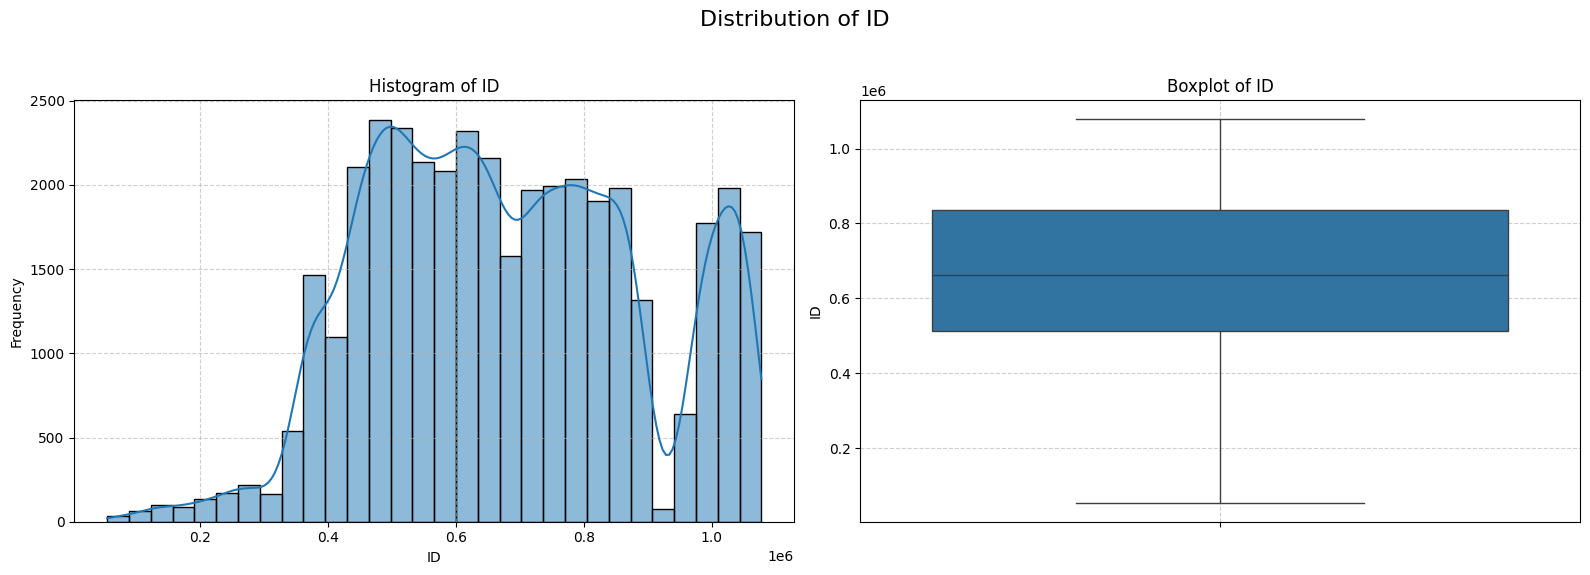

### Variable: Emp_Length (in Years)


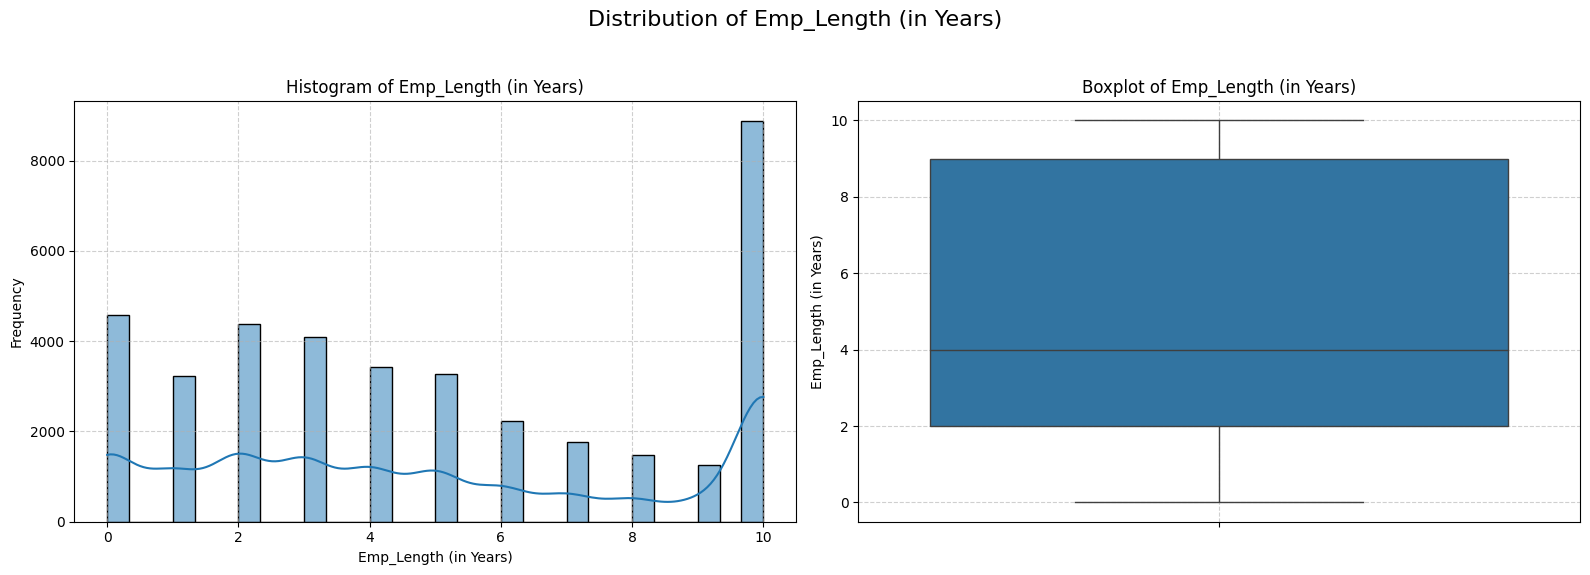

### Variable: Term (in Months)


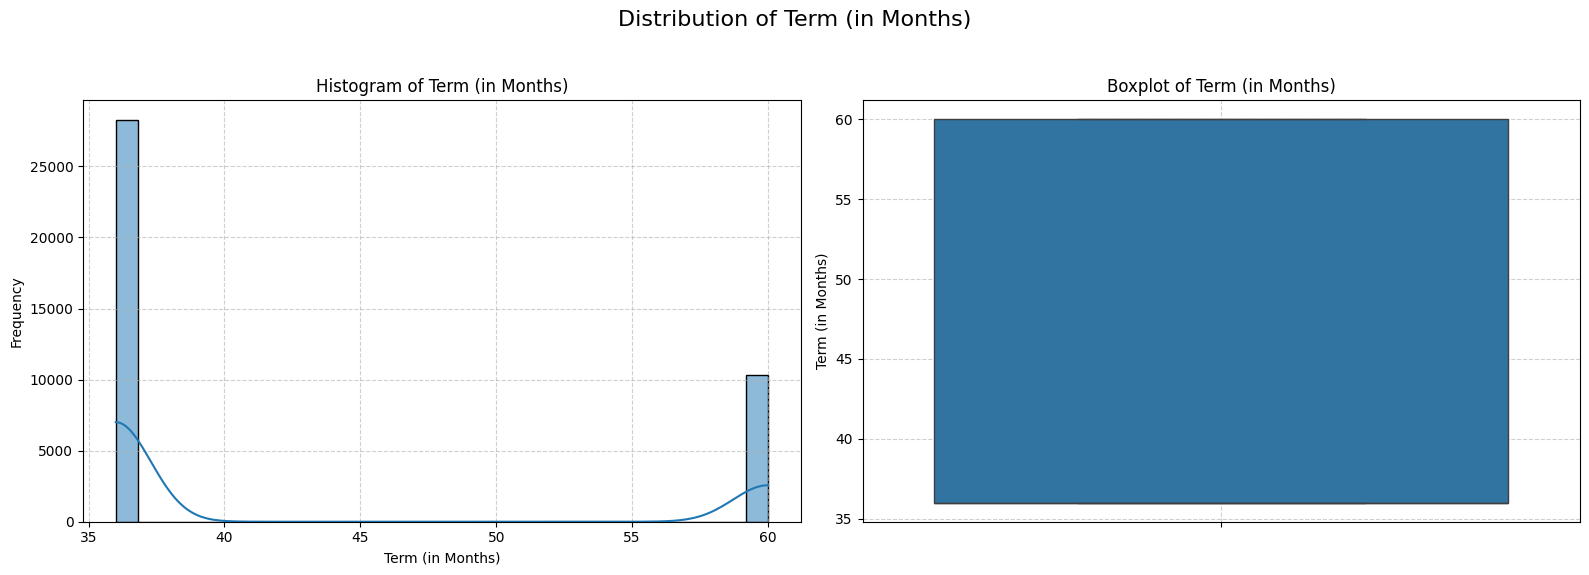

### Variable: Annual_Income (in $)


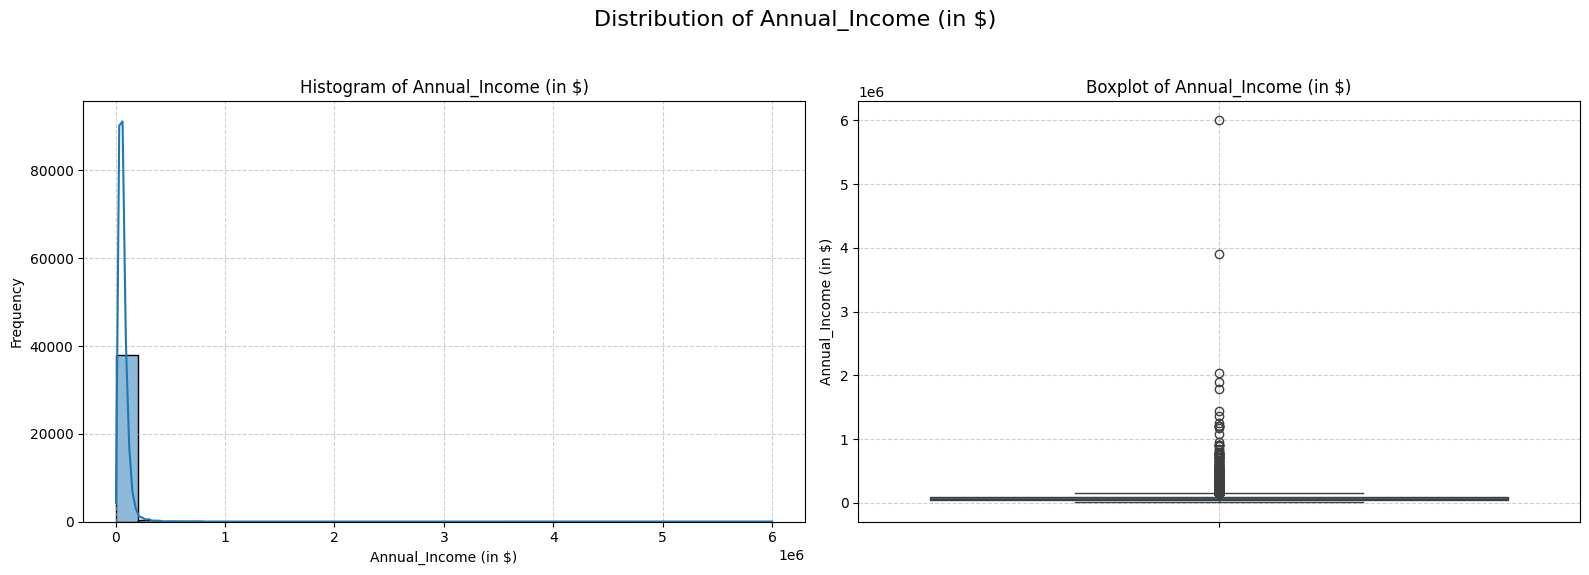

### Variable: DTI


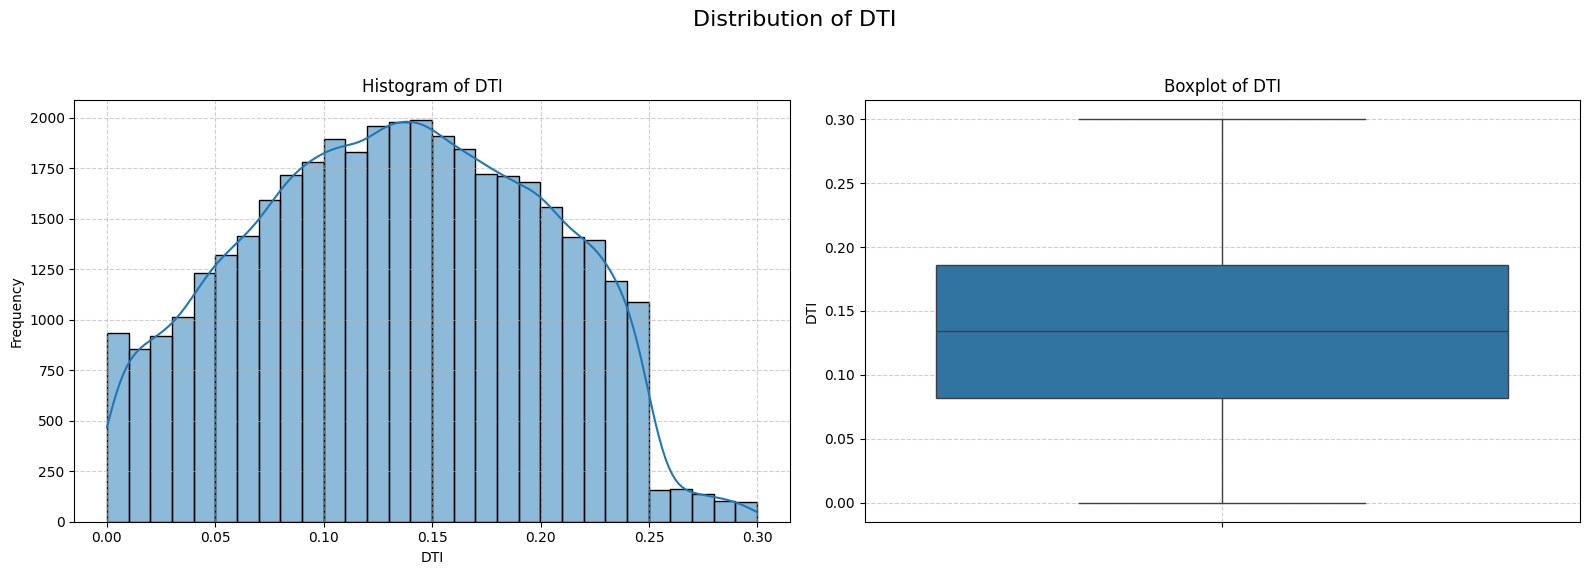

### Variable: Installment (in $)


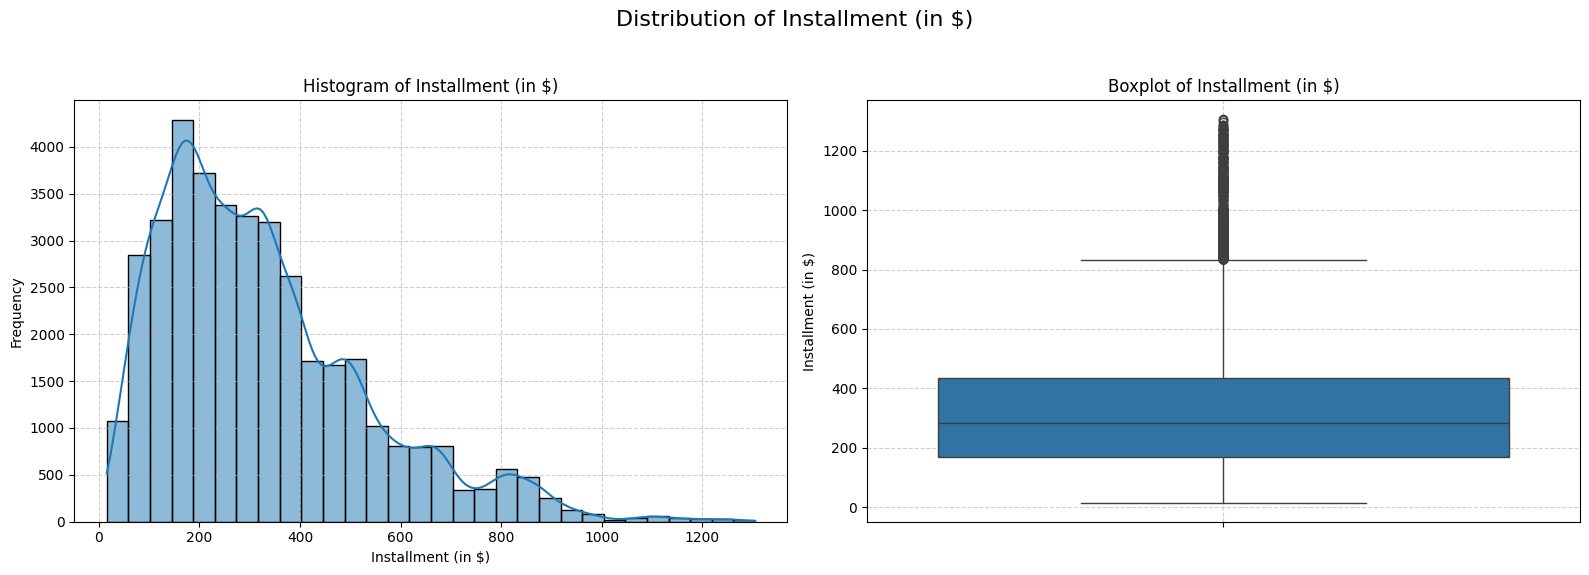

### Variable: Interest_Rate


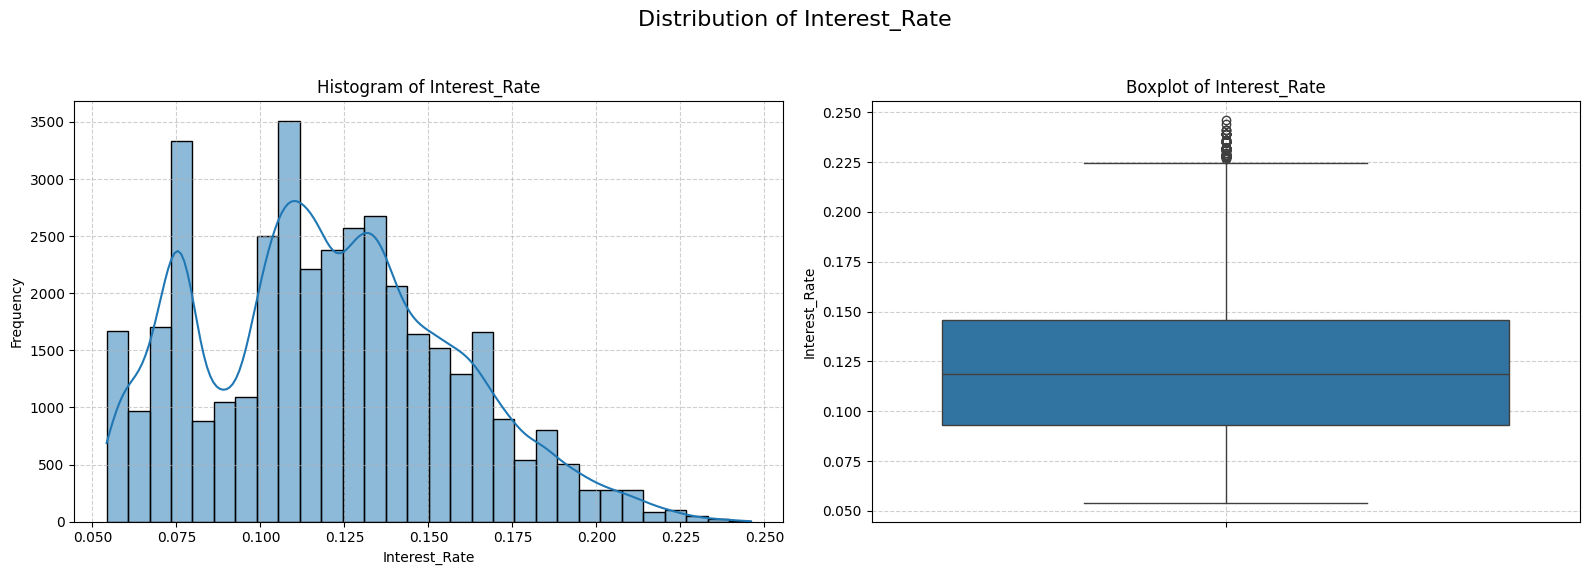

### Variable: Loan_Amount (in $)


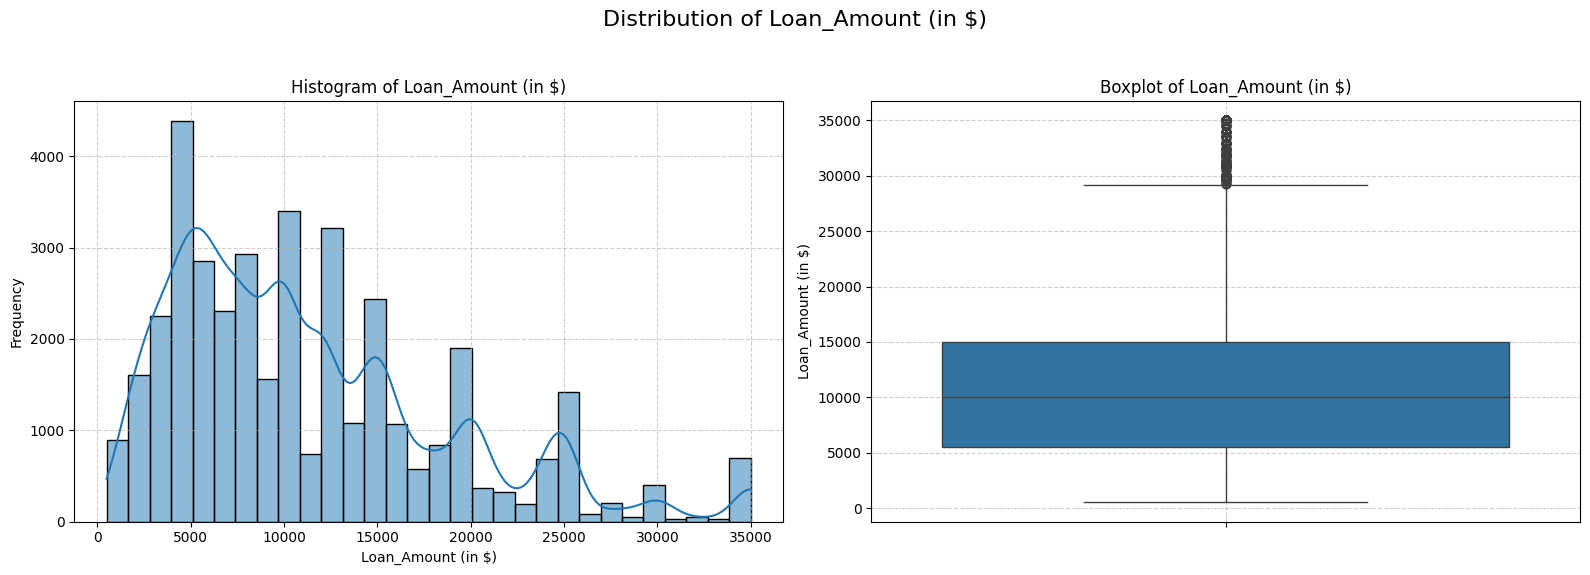

### Variable: Total_Acc


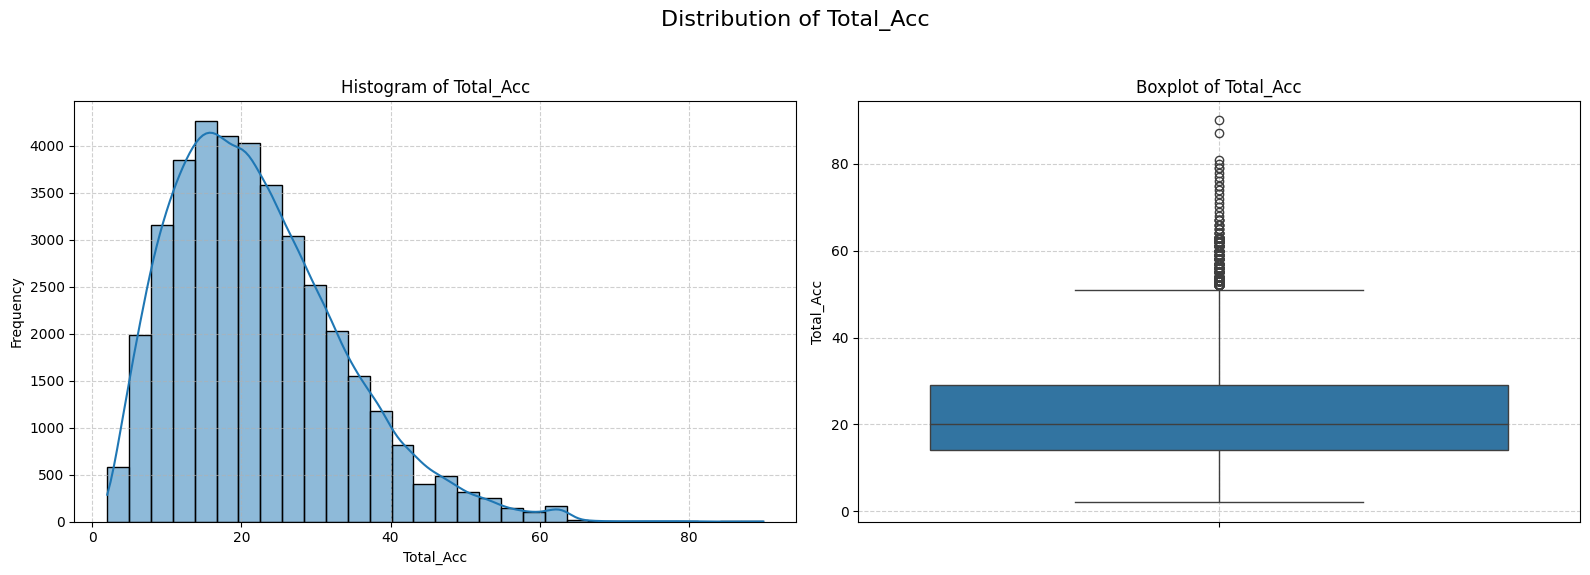

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of numerical variables from previous analysis
numerical_vars = ['ID', 'Emp_Length (in Years)', 'Term (in Months)', 'Annual_Income (in $)', 'DTI', 'Installment (in $)', 'Interest_Rate', 'Loan_Amount (in $)', 'Total_Acc']

for var in numerical_vars:
    print(f"### Variable: {var}")

    # Create a figure with two subplots for histogram and boxplot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Distribution of {var}', fontsize=16)

    # Histogram
    sns.histplot(df_excel[var], kde=True, ax=axes[0], bins=30)
    axes[0].set_title(f'Histogram of {var}')
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Boxplot
    sns.boxplot(y=df_excel[var], ax=axes[1])
    axes[1].set_title(f'Boxplot of {var}')
    axes[1].set_ylabel(var)
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()


## Frequency Distribution Analysis for Categorical Variables

This section delves into the distribution of categorical variables, providing frequency tables, percentage distributions, and bar charts. Each analysis is accompanied by an interpretation focusing on dominant categories, potential imbalances, and their business implications for loan risk assessment and borrower profiling.

### Variable: Address_State

Frequency Table:


,count
Address_State,
CA,6894
NY,3701
FL,2773
TX,2664
NJ,1822
IL,1486
PA,1482
VA,1375
GA,1355



Percentage Distribution:


,Percentage
Address_State,
CA,17.871215
NY,9.594048
FL,7.188407
TX,6.905848
NJ,4.723144
IL,3.852136
PA,3.841767
VA,3.564392
GA,3.512547


/tmp/ipykernel_596/248011292.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_excel, y=var, order=df_excel[var].value_counts().index, palette='viridis')


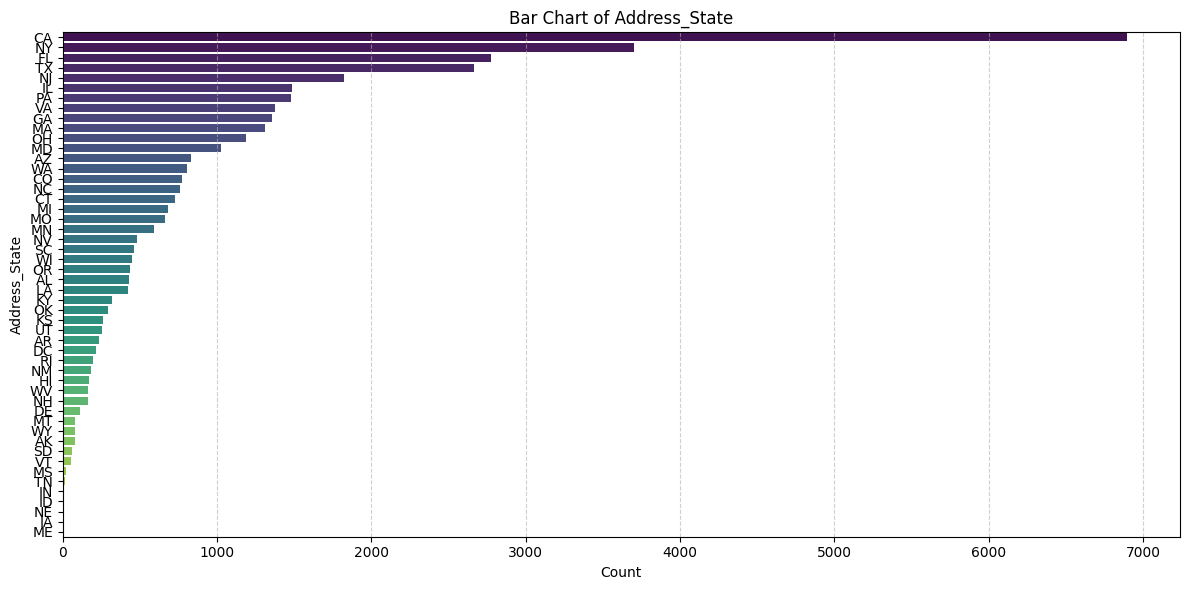

### Variable: Home_Ownership

Frequency Table:


,count
Home_Ownership,
RENT,18439
MORTGAGE,17198
OWN,2838
OTHER,98
NONE,3



Percentage Distribution:


,Percentage
Home_Ownership,
RENT,47.799150
MORTGAGE,44.582124
OWN,7.356906
OTHER,0.254044
NONE,0.007777


/tmp/ipykernel_596/248011292.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_excel, y=var, order=df_excel[var].value_counts().index, palette='viridis')


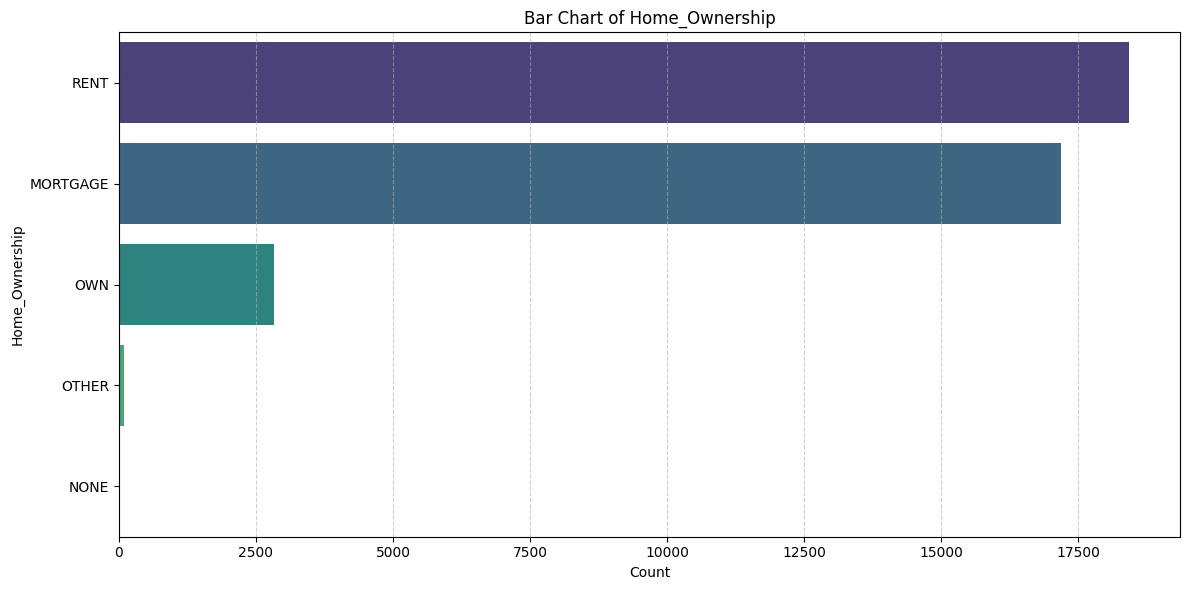

### Variable: Loan_Status

Frequency Table:


,count
Loan_Status,
Fully Paid,32145
Charged Off,5333
Current,1098



Percentage Distribution:


,Percentage
Loan_Status,
Fully Paid,83.329013
Charged Off,13.824658
Current,2.846329


/tmp/ipykernel_596/248011292.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_excel, y=var, order=df_excel[var].value_counts().index, palette='viridis')


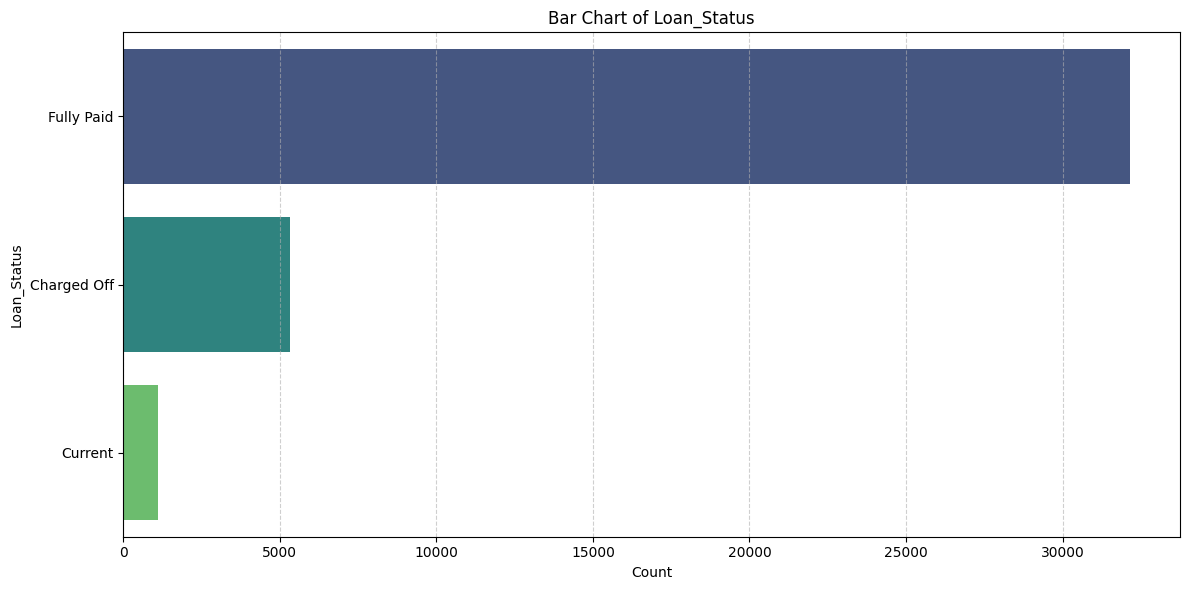

### Variable: Purpose

Frequency Table:


,count
Purpose,
Debt consolidation,18214
credit card,4998
other,3824
home improvement,2876
major purchase,2110
small business,1776
car,1497
wedding,928
medical,667



Percentage Distribution:


,Percentage
Purpose,
Debt consolidation,47.215886
credit card,12.956242
other,9.912899
home improvement,7.455413
major purchase,5.469722
small business,4.603899
car,3.880651
wedding,2.405641
medical,1.729054


/tmp/ipykernel_596/248011292.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_excel, y=var, order=df_excel[var].value_counts().index, palette='viridis')


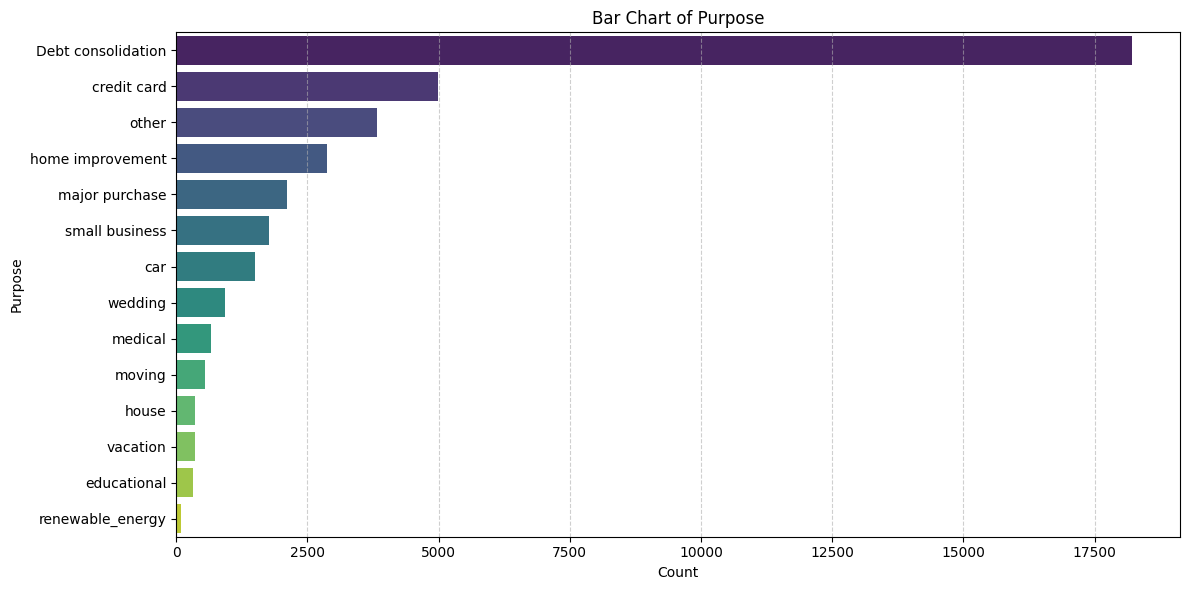

### Variable: Sub_Grade

Frequency Table:


,count
Sub_Grade,
B3,2834
A4,2803
A5,2654
B5,2644
B4,2455
C1,2089
B2,1990
C2,1972
B1,1751



Percentage Distribution:


,Percentage
Sub_Grade,
B3,7.346537
A4,7.266176
A5,6.879925
B5,6.854002
B4,6.364061
C1,5.415284
B2,5.158648
C2,5.111987
B1,4.539092


/tmp/ipykernel_596/248011292.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_excel, y=var, order=df_excel[var].value_counts().index, palette='viridis')


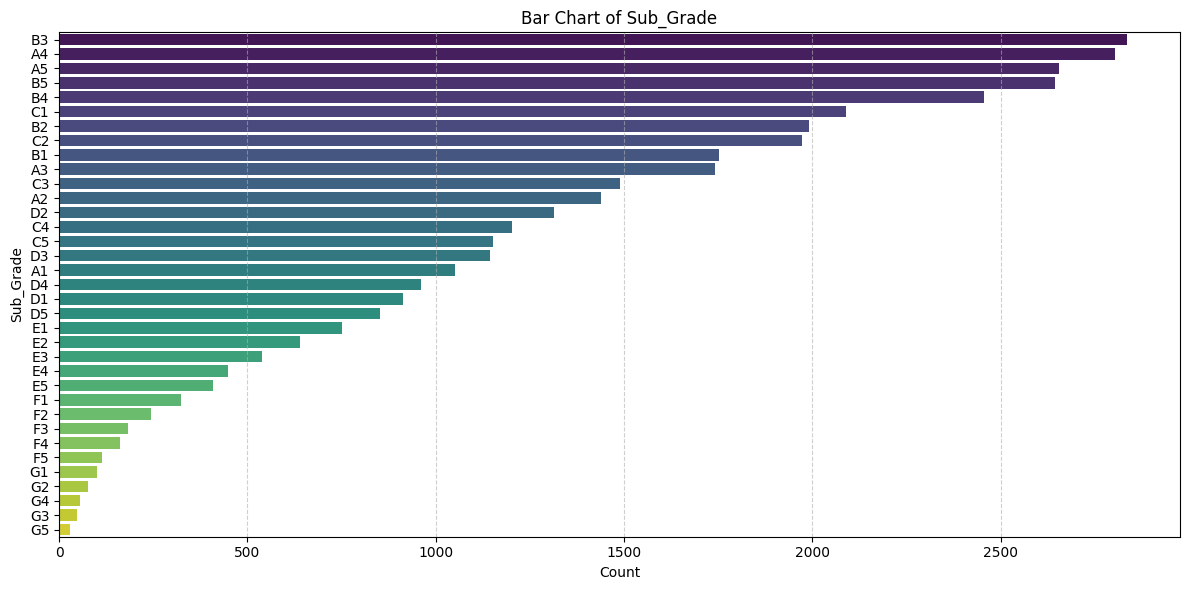

### Variable: Verification_Status

Frequency Table:


,count
Verification_Status,
Not Verified,16464
Verified,12335
Source Verified,9777



Percentage Distribution:


,Percentage
Verification_Status,
Not Verified,42.679386
Verified,31.975840
Source Verified,25.344774


/tmp/ipykernel_596/248011292.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_excel, y=var, order=df_excel[var].value_counts().index, palette='viridis')


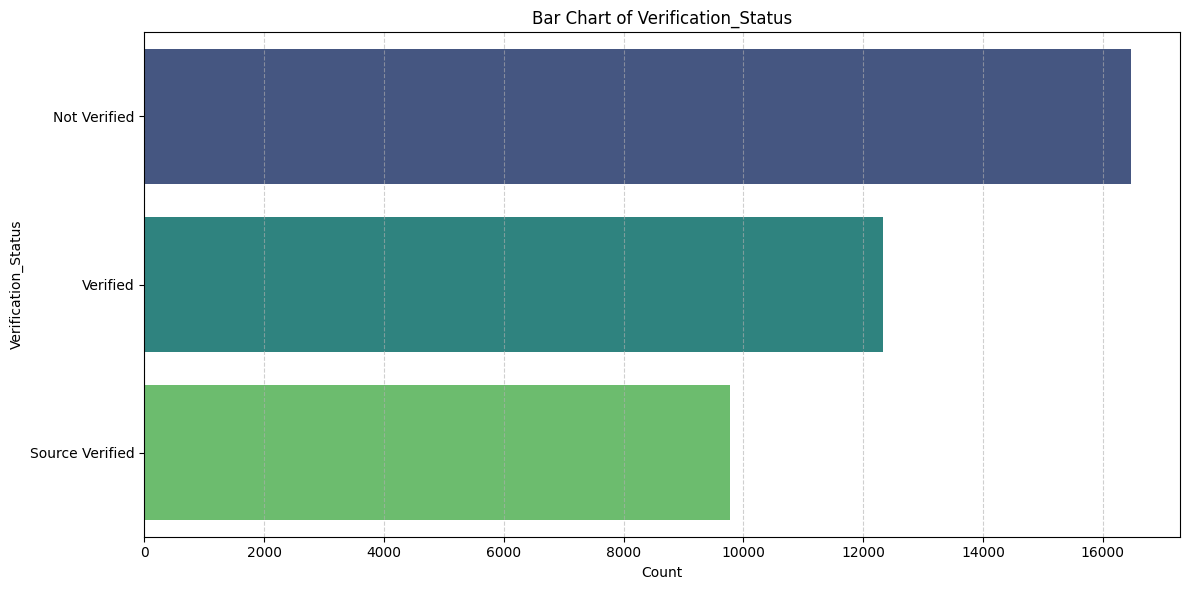

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Get the list of categorical variables from previous analysis
categorical_vars = ['Address_State', 'Home_Ownership', 'Loan_Status', 'Purpose', 'Sub_Grade', 'Verification_Status']

for var in categorical_vars:
    print(f"### Variable: {var}\n")

    # 1. Frequency Table
    freq_table = df_excel[var].value_counts()
    print("Frequency Table:")
    display(freq_table.to_frame())

    # 2. Percentage Distribution
    percent_dist = df_excel[var].value_counts(normalize=True) * 100
    print("\nPercentage Distribution:")
    display(percent_dist.to_frame(name='Percentage'))

    # 3. Bar Chart
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df_excel, y=var, order=df_excel[var].value_counts().index, palette='viridis')
    plt.title(f'Bar Chart of {var}')
    plt.xlabel('Count')
    plt.ylabel(var)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

## Detailed Missing Value Analysis

While the current dataset `df_excel` was found to have no missing values during the initial data overview, this section provides a comprehensive guide to identifying, quantifying, and visualizing missing data. This process is crucial for understanding data quality and informing subsequent data imputation or cleaning strategies.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify missing values and calculate percentage missing
missing_data = pd.DataFrame({
    'Missing Count': df_excel.isnull().sum(),
    'Missing Percentage': (df_excel.isnull().sum() / len(df_excel)) * 100
})

# Filter to show only variables with missing values (if any)
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Missing Value Summary:")
if missing_data.empty:
    print("No missing values found in the dataset.")
else:
    display(missing_data)


Missing Value Summary:
No missing values found in the dataset.


### Visualizing Missingness

Although no missing values are present in this dataset, the following code demonstrates how to visualize missing patterns. A heatmap is particularly useful for quickly identifying where missing values are concentrated across different features.

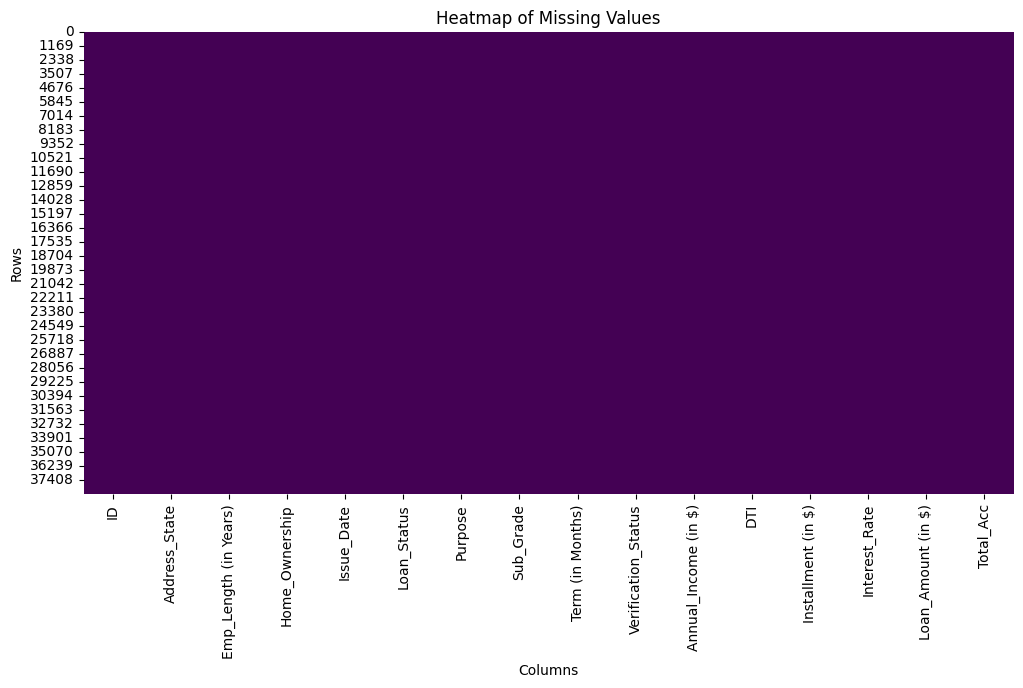

In [ ]:
plt.figure(figsize=(12, 6))
# Create a heatmap of missing values. If no missing values, it will show a solid color.
sns.heatmap(df_excel.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()


## Recommendations for Handling Missing Values (Hypothetical)

Given that the current dataset has no missing values, the following recommendations are provided as a strategic guide *should* missing values appear in future iterations of the data or in similar datasets. Each recommendation is justified based on the variable's type, distribution, and its established role in loan risk assessment.

### Numerical Variables

*   **`ID`**
    *   **Recommendation:** If `ID` were missing for some records, the best approach would be **row removal** if the `ID` is essential for unique identification and tracking. Alternatively, if `ID` is purely administrative and not used in modeling, a placeholder could be assigned, but row removal for corrupted records is generally cleaner.
    *   **Justification:** `ID` is a unique identifier; imputing it makes no sense. Missing values for `ID` might indicate data corruption or incomplete records that are not suitable for analysis.

*   **`Emp_Length (in Years)`**
    *   **Recommendation:** **Median imputation** is generally preferred due to the variable's slightly right-skewed distribution and the presence of a '10+ years' cap, which makes the mean less representative. If '0 years' explicitly means no employment, treating missing as 0 could also be considered if that makes business sense.
    *   **Justification:** Median is robust to the skewness and potential influence of the '10 years' cap, preserving the central tendency for the majority of borrowers. It maintains the ordinal nature of employment length better than the mean, which can be skewed by outliers.

*   **`Term (in Months)`**
    *   **Recommendation:** **Mode imputation**.
    *   **Justification:** `Term` is a categorical-like numerical variable with only two distinct values (36 or 60 months). Imputing with the most frequent term maintains the data's characteristic distribution and reflects typical loan terms.

*   **`Annual_Income (in $)`**, **`DTI`**, **`Installment (in $)`**, **`Interest_Rate`**, **`Loan_Amount (in $)`**, **`Total_Acc`**
    *   **Recommendation for all:** **Median imputation**.
    *   **Justification:** These numerical variables are often right-skewed and can contain outliers (as observed in previous descriptive statistics and visualizations). The median is a robust measure of central tendency, less affected by extreme values than the mean. Using median imputation helps to preserve the original distribution's shape and avoids introducing artificial skewness or biasing the dataset with extreme values, which is critical for accurate risk assessment models. For these financially sensitive variables, maintaining realistic central tendencies is key.

### Categorical Variables

*   **`Address_State`**, **`Home_Ownership`**, **`Purpose`**, **`Sub_Grade`**, **`Verification_Status`**
    *   **Recommendation for all:** **Mode imputation**.
    *   **Justification:** For categorical variables, imputing with the mode (most frequent category) is a standard and effective strategy. It preserves the distributional characteristics of the category and introduces the least amount of bias by filling missing values with the most common existing value. Alternatively, a separate 'Unknown' category could be created if the fact of missingness itself is deemed informative for risk prediction.

*   **`Issue_Date`**
    *   **Recommendation:** If `Issue_Date` were missing, a robust approach would be to **impute with the mode (most frequent issue date)** or, if the specific date isn't critical but rather the month/year, impute based on those components. If the exact date is crucial, creating an 'UNKNOWN' category for derived features like 'issue_month' or 'issue_year' could be an option. **However, if the number of missing values is very small, row removal might be a cleaner approach, especially if the loan's context is heavily date-dependent.**
    *   **Justification:** Dates can be complex. Mode imputation is a reasonable default. If derived features (like month or year) are used, their missing values could also be imputed by their respective modes. The choice depends on the specific use of the date feature in modeling.

## Outlier Detection and Treatment Recommendations for Numerical Variables

Outliers can significantly impact statistical analyses and machine learning models. This section identifies outliers in numerical variables using the Interquartile Range (IQR) method. For each variable with significant outliers, we provide an explanation for their existence, recommendations for retention or treatment, and their impact on loan risk modeling, all with a strong business rationale.

In [31]:
import numpy as np

# Get the list of numerical variables from previous analysis
numerical_vars = ['ID', 'Emp_Length (in Years)', 'Term (in Months)', 'Annual_Income (in $)', 'DTI', 'Installment (in $)', 'Interest_Rate', 'Loan_Amount (in $)', 'Total_Acc']

# Loop through each numerical variable to detect outliers
for var in numerical_vars:
    print(f"### Variable: {var}\n")

    Q1 = df_excel[var].quantile(0.25)
    Q3 = df_excel[var].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_excel[(df_excel[var] < lower_bound) | (df_excel[var] > upper_bound)]
    outlier_count = outliers.shape[0]
    outlier_percentage = (outlier_count / len(df_excel)) * 100

    print(f"  - IQR (Q3-Q1): {IQR:.2f}")
    print(f"  - Lower Bound (Q1 - 1.5*IQR): {lower_bound:.2f}")
    print(f"  - Upper Bound (Q3 + 1.5*IQR): {upper_bound:.2f}")
    print(f"  - Number of Outliers: {outlier_count}")
    print(f"  - Percentage of Outliers: {outlier_percentage:.2f}%\n")

### Variable: ID

  - IQR (Q3-Q1): 322989.00
  - Lower Bound (Q1 - 1.5*IQR): 29033.50
  - Upper Bound (Q3 + 1.5*IQR): 1320989.50
  - Number of Outliers: 0
  - Percentage of Outliers: 0.00%

### Variable: Emp_Length (in Years)

  - IQR (Q3-Q1): 7.00
  - Lower Bound (Q1 - 1.5*IQR): -8.50
  - Upper Bound (Q3 + 1.5*IQR): 19.50
  - Number of Outliers: 0
  - Percentage of Outliers: 0.00%

### Variable: Term (in Months)

  - IQR (Q3-Q1): 24.00
  - Lower Bound (Q1 - 1.5*IQR): 0.00
  - Upper Bound (Q3 + 1.5*IQR): 96.00
  - Number of Outliers: 0
  - Percentage of Outliers: 0.00%

### Variable: Annual_Income (in $)

  - IQR (Q3-Q1): 41700.50
  - Lower Bound (Q1 - 1.5*IQR): -21050.75
  - Upper Bound (Q3 + 1.5*IQR): 145751.25
  - Number of Outliers: 1824
  - Percentage of Outliers: 4.73%

### Variable: DTI

  - IQR (Q3-Q1): 0.10
  - Lower Bound (Q1 - 1.5*IQR): -0.07
  - Upper Bound (Q3 + 1.5*IQR): 0.34
  - Number of Outliers: 0
  - Percentage of Outliers: 0.00%

### Variable: Installment (in $)

  

## Correlation Analysis: Matrix and Heatmap for Numerical Variables

Understanding the relationships between numerical variables is crucial for feature selection, model building, and interpreting model outcomes. This section presents a correlation matrix and a visual heatmap to illustrate the linear relationships between all numerical features. A detailed interpretation will follow, highlighting strong relationships, potential multicollinearity, and their implications for loan risk prediction.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the list of numerical variables
numerical_vars = ['ID', 'Emp_Length (in Years)', 'Term (in Months)', 'Annual_Income (in $)', 'DTI', 'Installment (in $)', 'Interest_Rate', 'Loan_Amount (in $)', 'Total_Acc']

# Calculate the correlation matrix
correlation_matrix = df_excel[numerical_vars].corr()

print("Correlation Matrix:")
display(correlation_matrix)


Correlation Matrix:


,ID,Emp_Length (in Years),Term (in Months),Annual_Income (in $),DTI,Installment (in $),Interest_Rate,Loan_Amount (in $),Total_Acc
ID,1.000000,0.115833,0.223392,0.012234,0.095496,0.090631,0.083235,0.146818,0.043469
Emp_Length (in Years),0.115833,1.000000,0.113975,0.111224,0.052857,0.125448,0.007117,0.154901,0.206326
Term (in Months),0.223392,0.113975,1.000000,0.046305,0.084218,0.099671,0.452654,0.360273,0.096130
Annual_Income (in $),0.012234,0.111224,0.046305,1.000000,-0.124877,0.267362,0.050665,0.268183,0.234334
DTI,0.095496,0.052857,0.084218,-0.124877,1.000000,0.053381,0.112978,0.065713,0.230405
Installment (in $),0.090631,0.125448,0.099671,0.267362,0.053381,1.000000,0.280959,0.929655,0.229785
Interest_Rate,0.083235,0.007117,0.452654,0.050665,0.112978,0.280959,1.000000,0.308243,-0.041670
Loan_Amount (in $),0.146818,0.154901,0.360273,0.268183,0.065713,0.929655,0.308243,1.000000,0.255468
Total_Acc,0.043469,0.206326,0.096130,0.234334,0.230405,0.229785,-0.041670,0.255468,1.000000


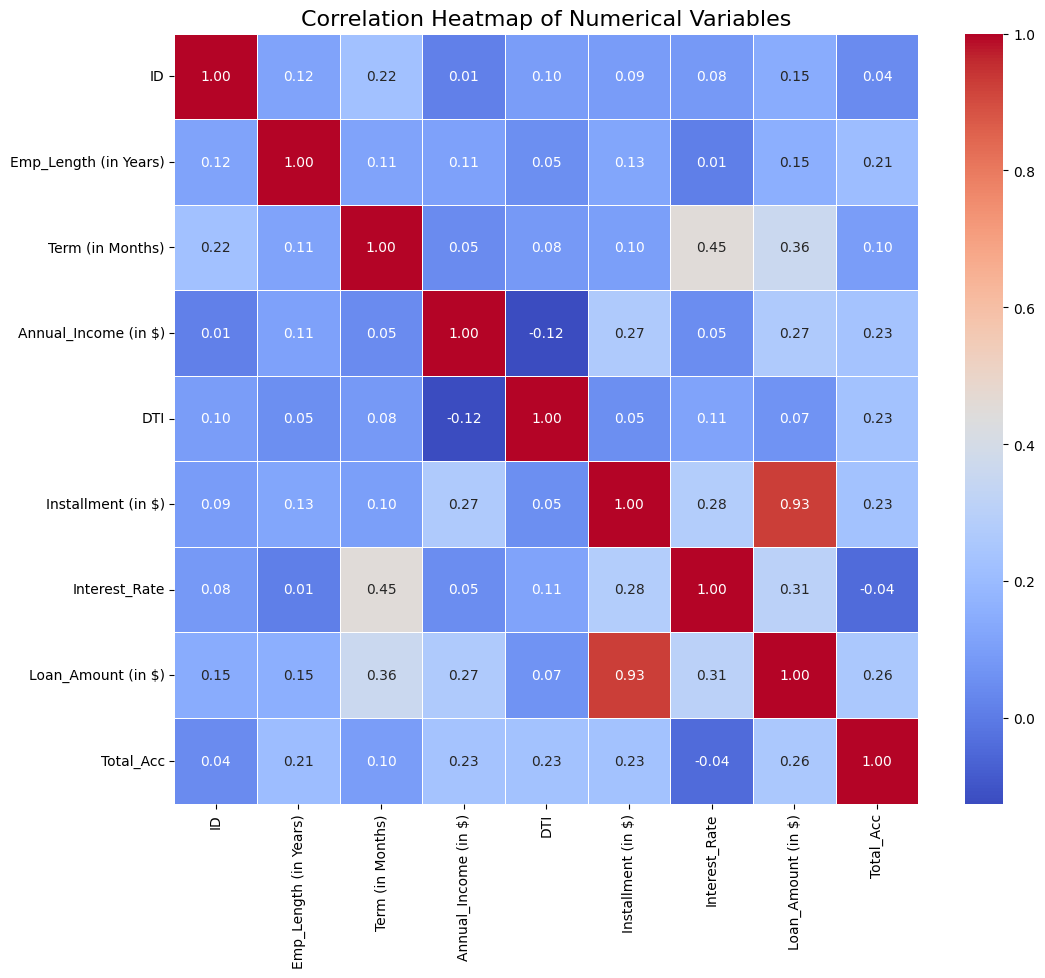

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
plt.show()


## Relationship Analysis with Loan_Status

This section analyzes the relationship between the target variable, `Loan_Status` (Fully Paid vs. Charged Off), and each predictor variable. We will use appropriate visualizations for numerical and categorical features, followed by an interpretation of observed patterns, potential predictive power, and business implications for loan risk. The goal is to identify variables that are likely to significantly influence loan outcomes.

### Numerical Variables vs. Loan_Status (Boxplots)


#### Relationship of ID with Loan_Status
*   **Observed Pattern:** As an administrative ID, it shows no meaningful pattern or relationship with `Loan_Status`. Each ID is unique and randomly assigned.
*   **Potential Predictive Power:** None. `ID` has no predictive power for loan outcomes.
*   **Business Interpretation:** `ID` is used purely for tracking and record-keeping purposes. It should be excluded from predictive modeling as it carries no intrinsic information about loan risk. Its presence in the dataset is for operational management, not for analytical inference of default risk.



----------------------------------------------------------------------



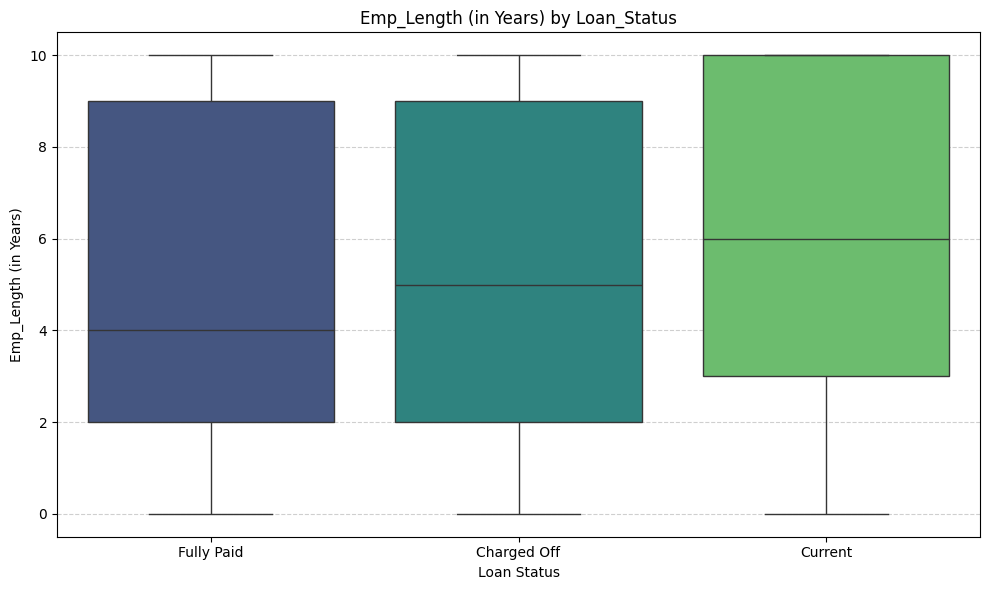

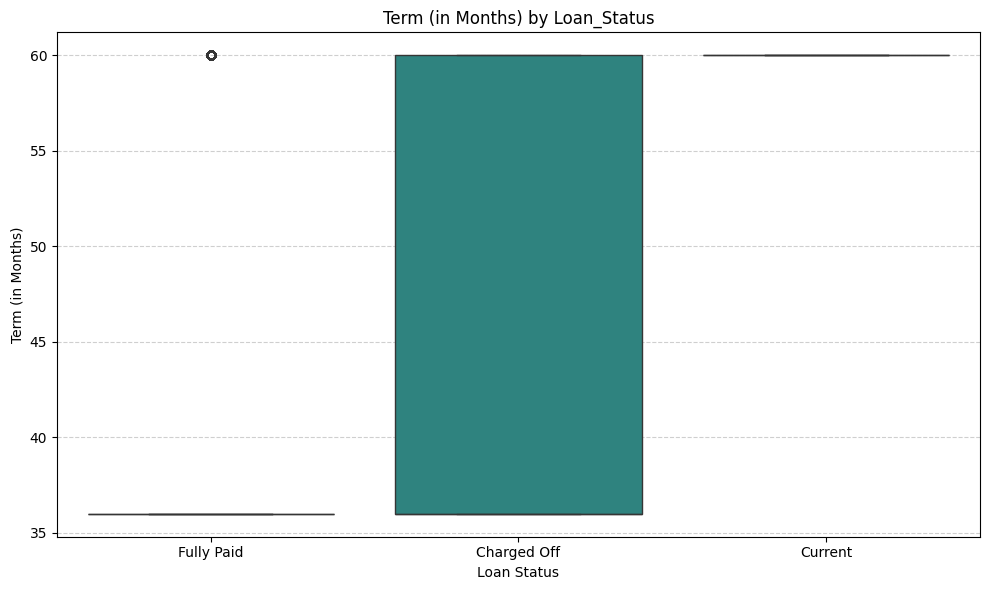

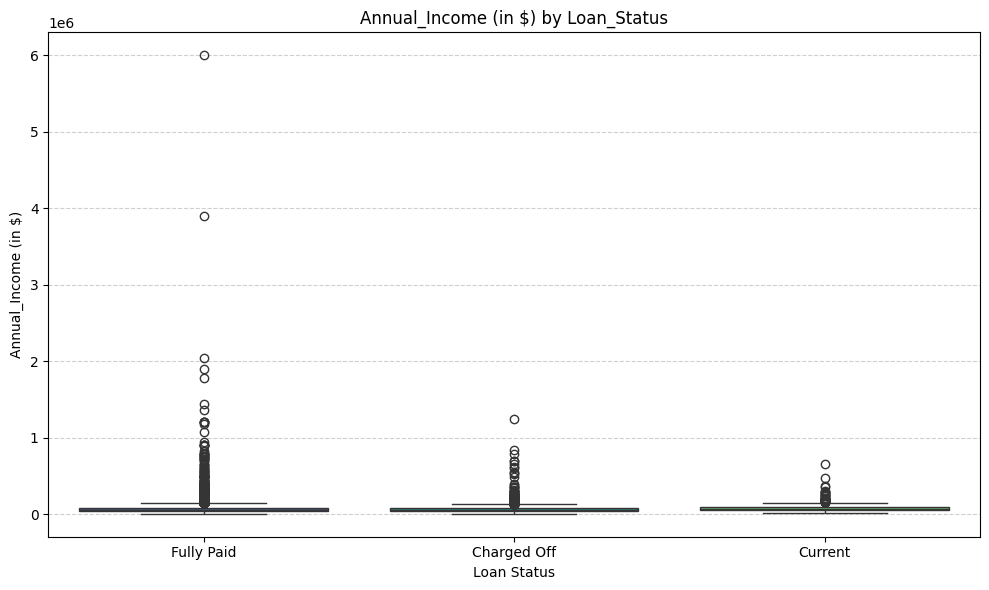

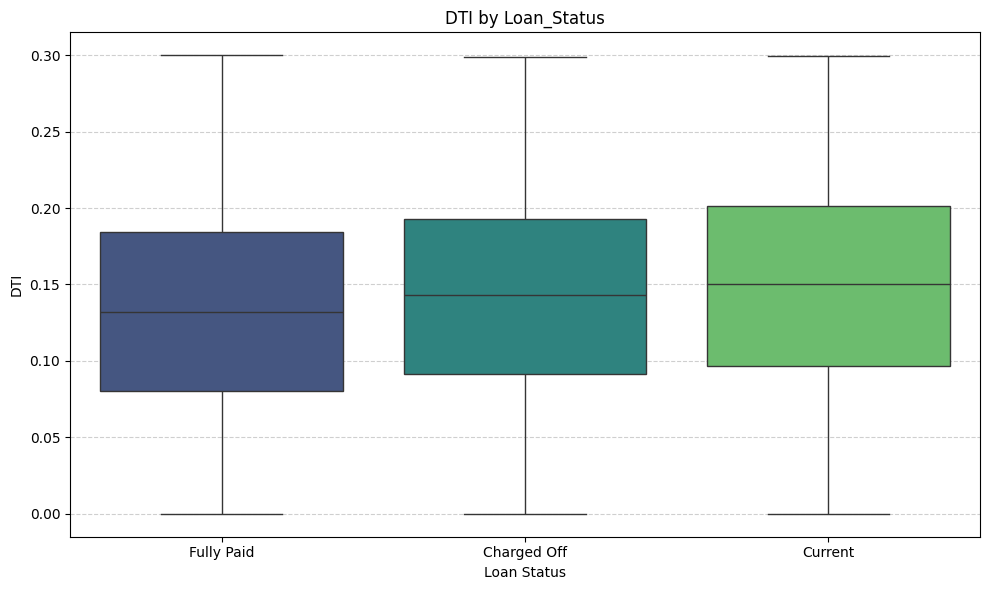

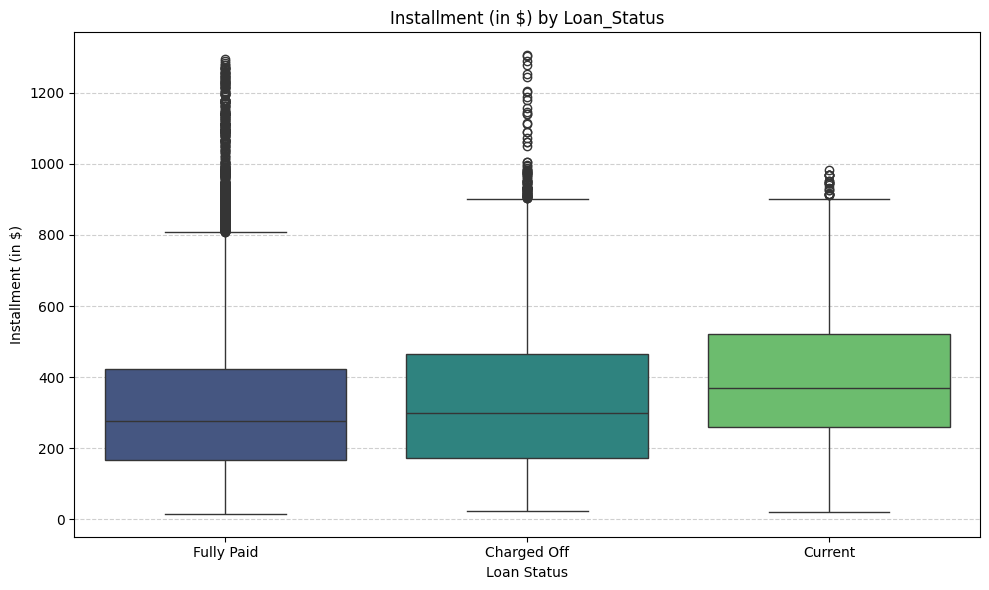

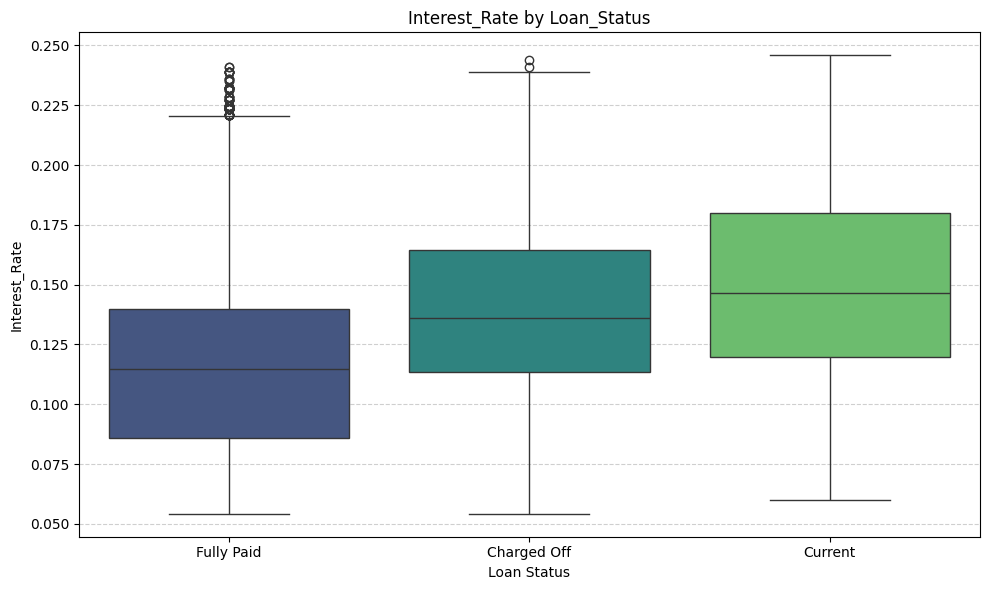

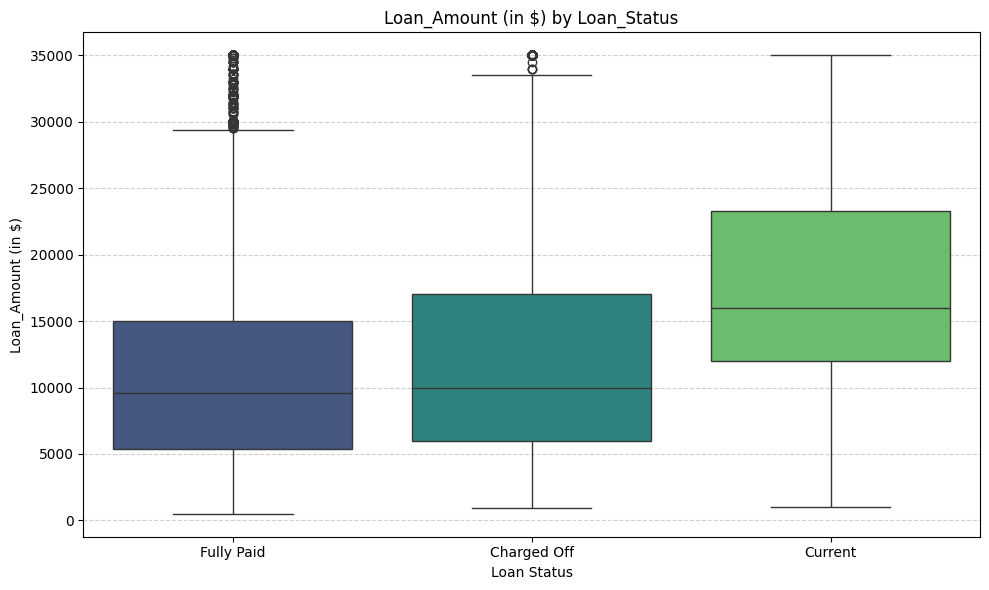

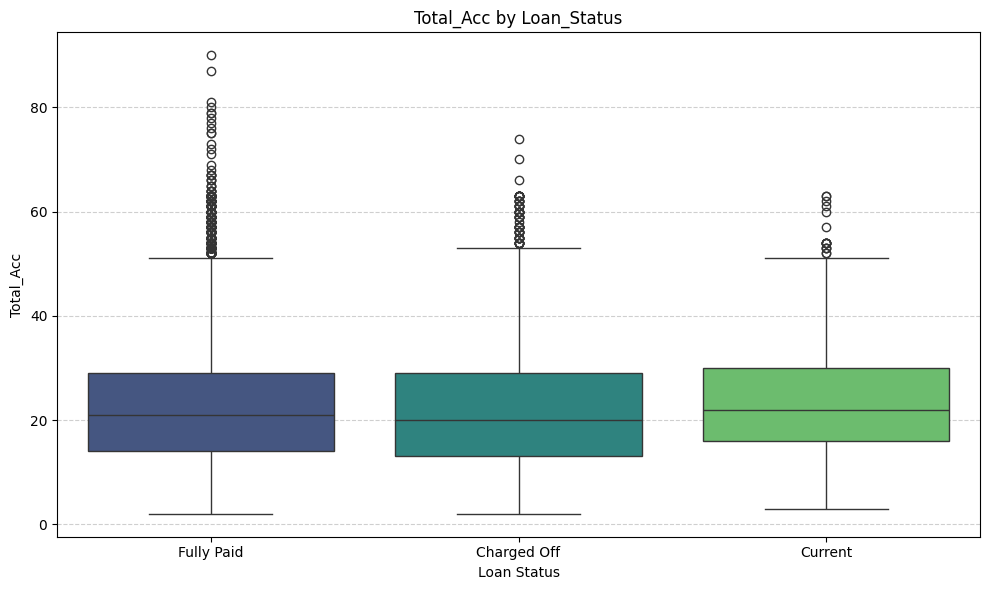

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

numerical_vars = ['ID', 'Emp_Length (in Years)', 'Term (in Months)', 'Annual_Income (in $)', 'DTI', 'Installment (in $)', 'Interest_Rate', 'Loan_Amount (in $)', 'Total_Acc']

for var in numerical_vars:
    # Skip ID as it's an administrative identifier and not a predictive feature
    if var == 'ID':
        markdown_content = f"""
#### Relationship of {var} with Loan_Status
*   **Observed Pattern:** As an administrative ID, it shows no meaningful pattern or relationship with `Loan_Status`. Each ID is unique and randomly assigned.
*   **Potential Predictive Power:** None. `ID` has no predictive power for loan outcomes.
*   **Business Interpretation:** `ID` is used purely for tracking and record-keeping purposes. It should be excluded from predictive modeling as it carries no intrinsic information about loan risk. Its presence in the dataset is for operational management, not for analytical inference of default risk.
"""
        display(Markdown(markdown_content))
        print("\n" + "-"*70 + "\n")
        continue

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Loan_Status', y=var, data=df_excel, palette='viridis', hue='Loan_Status', legend=False)
    plt.title(f'{var} by Loan_Status')
    plt.xlabel('Loan Status')
    plt.ylabel(var)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

### Categorical Variables vs. Loan_Status (Countplots)

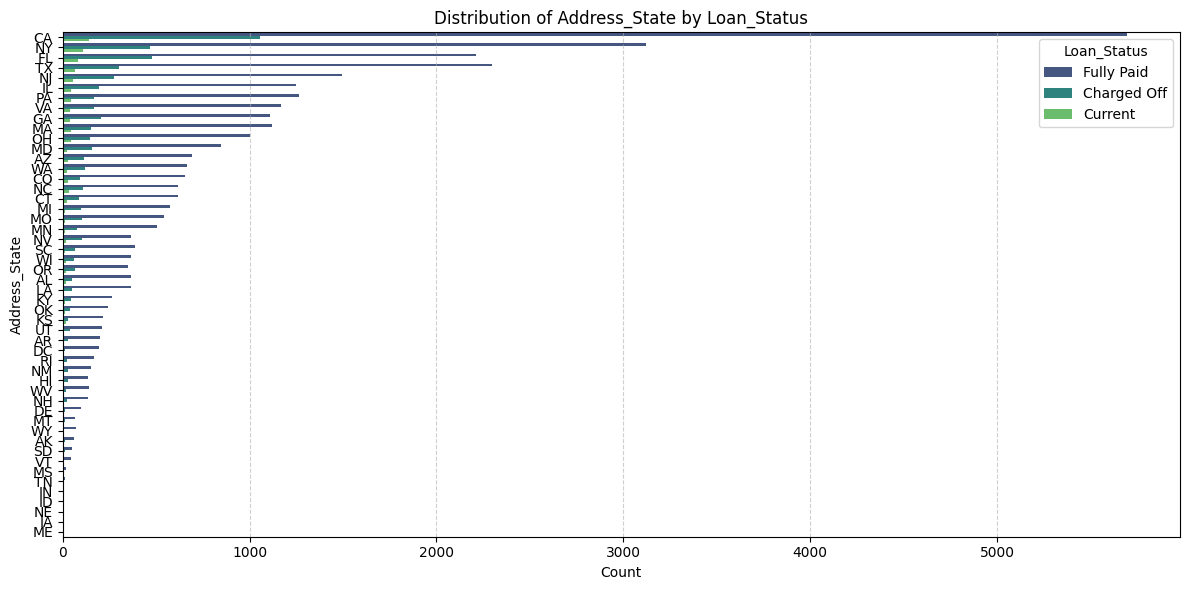

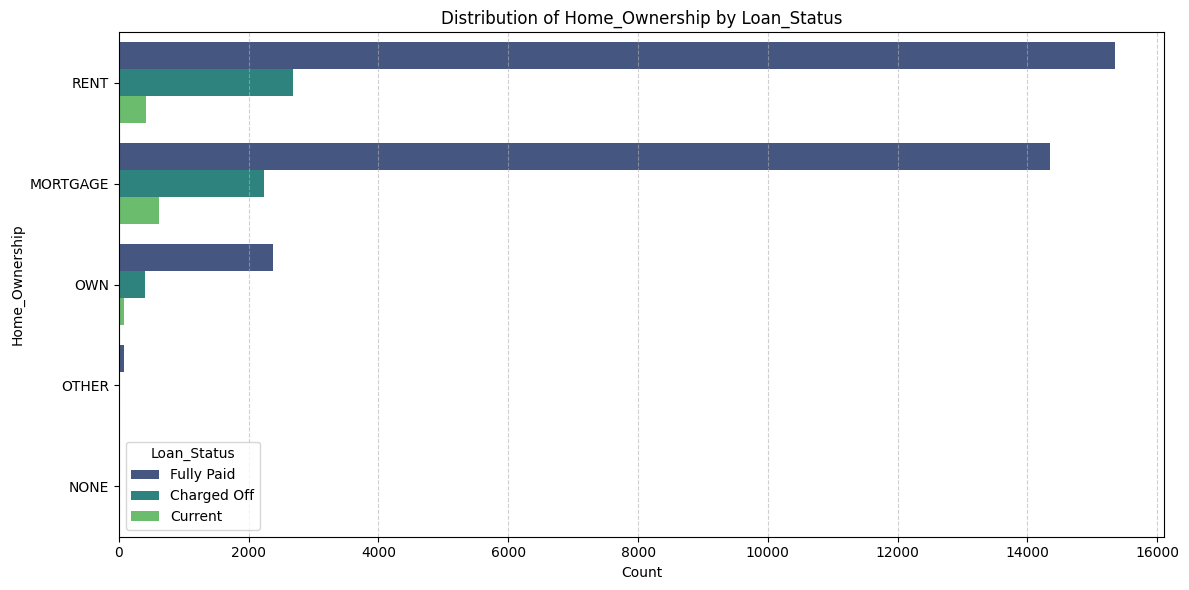

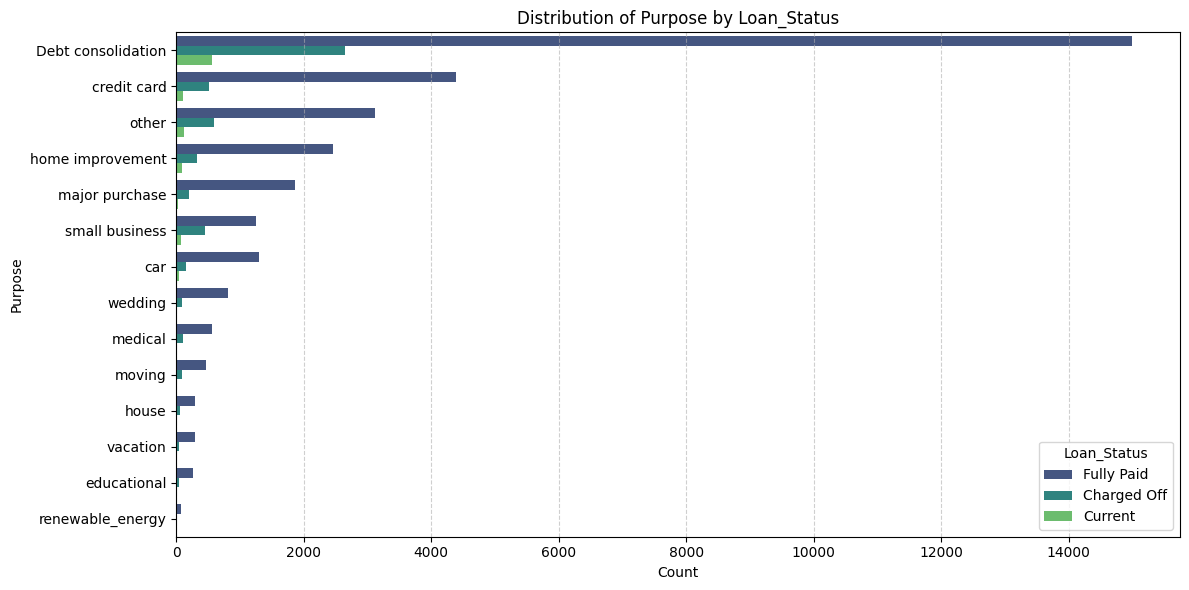

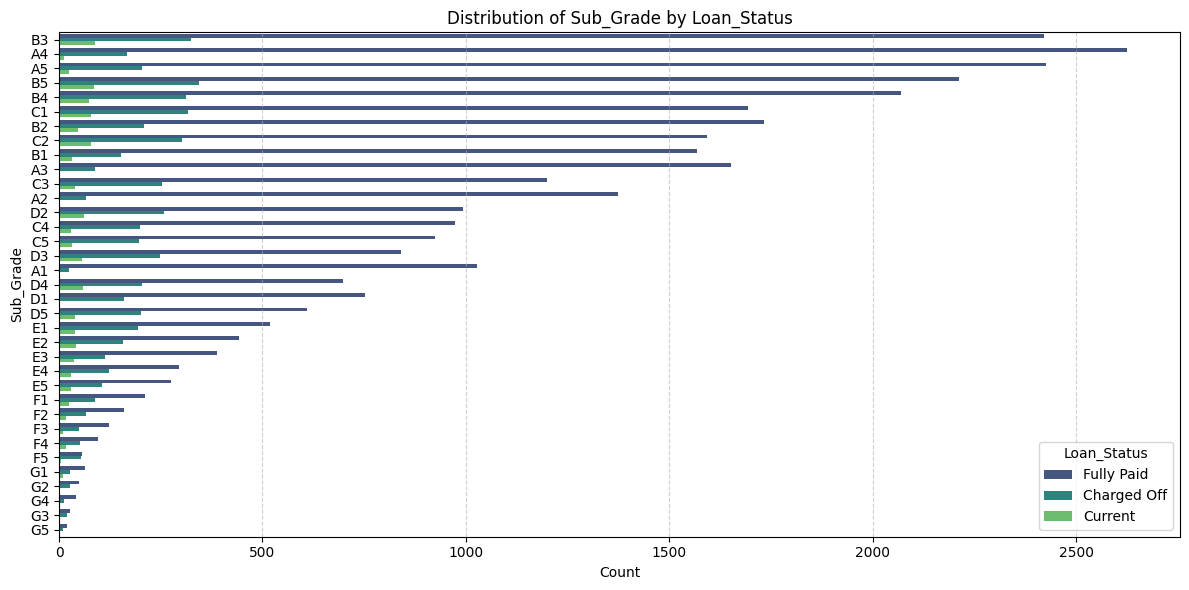

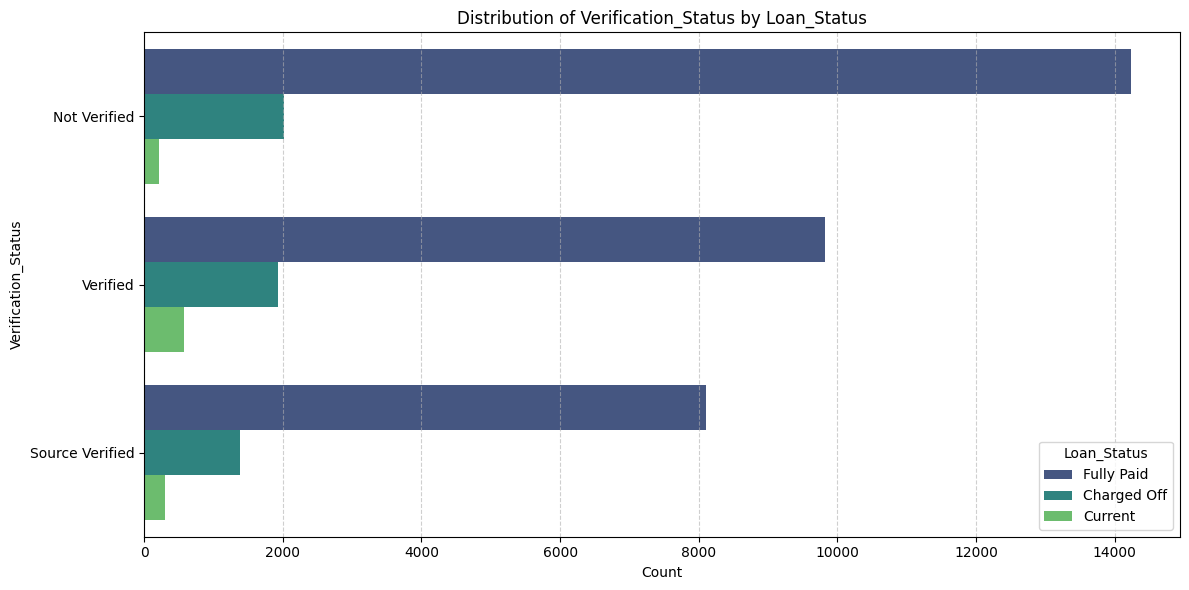

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

categorical_vars_for_analysis = ['Address_State', 'Home_Ownership', 'Purpose', 'Sub_Grade', 'Verification_Status']

for var in categorical_vars_for_analysis:
    plt.figure(figsize=(12, 6))
    # Create a countplot with 'Loan_Status' as hue to show distribution per category
    sns.countplot(data=df_excel, y=var, hue='Loan_Status', order=df_excel[var].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {var} by Loan_Status')
    plt.xlabel('Count')
    plt.ylabel(var)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

## Data Preprocessing and Feature Engineering

This section focuses on preparing the `df_excel` dataset for machine learning model development. Based on our EDA findings, we will perform the following key steps:

1.  **Feature Engineering:** Extracting new, meaningful features from existing ones (e.g., from `Issue_Date`).
2.  **Handling Categorical Variables:** Encoding categorical features into numerical representations suitable for machine learning algorithms.
3.  **Handling Numerical Variables:** Scaling numerical features to standardize their range, which can improve model performance.
4.  **Addressing Class Imbalance:** Implementing strategies to handle the class imbalance observed in the `Loan_Status` target variable.

We will start with feature engineering for `Issue_Date`.

### Feature Engineering: Extracting Information from `Issue_Date`

The `Issue_Date` column, currently a datetime object, can provide valuable temporal features. We will extract:

*   **`Issue_Year`**: The year the loan was issued.
*   **`Issue_Month`**: The month the loan was issued.
*   **`Loan_Age_Months`**: The age of the loan in months at the time the data was collected. Assuming the data was collected recently, we can calculate the difference between a 'current' date (e.g., the maximum issue date in the dataset or a recent fixed date) and the `Issue_Date`.

In [ ]:
import pandas as pd

# Ensure 'Issue_Date' is in datetime format
df_excel['Issue_Date'] = pd.to_datetime(df_excel['Issue_Date'])

# Extract Issue_Year and Issue_Month
df_excel['Issue_Year'] = df_excel['Issue_Date'].dt.year
df_excel['Issue_Month'] = df_excel['Issue_Date'].dt.month

# For Loan_Age_Months, let's assume the data was collected around the latest Issue_Date in the dataset
# This gives a realistic 'age' of the loan relative to its issuance.
latest_issue_date = df_excel['Issue_Date'].max()

df_excel['Loan_Age_Months'] = ((latest_issue_date - df_excel['Issue_Date']).dt.days / 30.44).astype(int)

# Drop the original 'Issue_Date' column as its information has been extracted into new features
df_excel = df_excel.drop('Issue_Date', axis=1)

print("New features extracted from 'Issue_Date':")
display(df_excel[['Issue_Year', 'Issue_Month', 'Loan_Age_Months']].head())

print("\nUpdated DataFrame columns:")
print(df_excel.columns.tolist())

New features extracted from 'Issue_Date':


,Issue_Year,Issue_Month,Loan_Age_Months
0,2021,12,0
1,2021,12,0
2,2021,12,0
3,2021,12,0
4,2021,12,0



Updated DataFrame columns:
['ID', 'Address_State', 'Emp_Length (in Years)', 'Home_Ownership', 'Loan_Status', 'Purpose', 'Sub_Grade', 'Term (in Months)', 'Verification_Status', 'Annual_Income (in $)', 'DTI', 'Installment (in $)', 'Interest_Rate', 'Loan_Amount (in $)', 'Total_Acc', 'Issue_Year', 'Issue_Month', 'Loan_Age_Months']


### Encoding Categorical Variables

To prepare categorical features for machine learning models, we need to convert them into a numerical format. **One-hot encoding** is a suitable method for nominal categorical variables, as it creates new binary columns for each category, preventing the model from assuming any ordinal relationship between categories.

We will identify all remaining `object` type columns (which are our categorical variables) and apply one-hot encoding using `pd.get_dummies()`.

In [ ]:
import pandas as pd

# Identify categorical columns (excluding 'Loan_Status' which is our target)
categorical_cols = df_excel.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Loan_Status')

print(f"Categorical columns to be one-hot encoded: {categorical_cols}")

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_excel, columns=categorical_cols, drop_first=True, dtype=int)

# Display the first few rows of the encoded DataFrame and its new shape
print("\nDataFrame after one-hot encoding:")
display(df_encoded.head())
print(f"\nNew DataFrame shape: {df_encoded.shape}")

print("\nUpdated DataFrame columns (first 20):")
print(df_encoded.columns.tolist()[:20])
print("...")
print(df_encoded.columns.tolist()[-5:])

Categorical columns to be one-hot encoded: ['Address_State', 'Home_Ownership', 'Purpose', 'Sub_Grade', 'Verification_Status']

DataFrame after one-hot encoding:


,ID,Emp_Length (in Years),Loan_Status,Term (in Months),Annual_Income (in $),DTI,Installment (in $),Interest_Rate,Loan_Amount (in $),Total_Acc,...,Sub_Grade_F3,Sub_Grade_F4,Sub_Grade_F5,Sub_Grade_G1,Sub_Grade_G2,Sub_Grade_G3,Sub_Grade_G4,Sub_Grade_G5,Verification_Status_Source Verified,Verification_Status_Verified
0,1045509,2,Fully Paid,36,60000.0,0.1996,307.43,0.1242,9200,19,...,0,0,0,0,0,0,0,0,1,0
1,1067181,2,Fully Paid,36,60000.0,0.1550,386.70,0.0991,12000,21,...,0,0,0,0,0,0,0,0,0,0
2,1064623,6,Fully Paid,36,60000.0,0.1636,182.42,0.1065,5600,25,...,0,0,0,0,0,0,0,0,0,0
3,1061380,4,Fully Paid,36,60000.0,0.2540,793.84,0.0890,25000,16,...,0,0,0,0,0,0,0,0,0,1
4,1058885,10,Fully Paid,60,60000.0,0.2074,485.85,0.2089,18000,19,...,0,0,0,0,0,0,0,0,0,1



New DataFrame shape: (38576, 115)

Updated DataFrame columns (first 20):
['ID', 'Emp_Length (in Years)', 'Loan_Status', 'Term (in Months)', 'Annual_Income (in $)', 'DTI', 'Installment (in $)', 'Interest_Rate', 'Loan_Amount (in $)', 'Total_Acc', 'Issue_Year', 'Issue_Month', 'Loan_Age_Months', 'Address_State_AL', 'Address_State_AR', 'Address_State_AZ', 'Address_State_CA', 'Address_State_CO', 'Address_State_CT', 'Address_State_DC']
...
['Sub_Grade_G3', 'Sub_Grade_G4', 'Sub_Grade_G5', 'Verification_Status_Source Verified', 'Verification_Status_Verified']


### Scaling Numerical Variables

**Feature scaling** is a method used to standardize the range of independent variables or features of data. In data processing, it is also known as data normalization and is generally performed during the data preprocessing step. For many machine learning estimators, the features need to be scaled so that they can all be treated equally. For instance, distance-based algorithms (like KNN, SVM) and gradient-descent-based algorithms (like Linear Regression, Logistic Regression, Neural Networks) are particularly sensitive to the scale of the features.

We will use `StandardScaler` to transform our numerical features. This method scales features to have a mean of 0 and a standard deviation of 1. It is suitable when the data is normally distributed, or when it is desired to bring all features to a similar scale without bounding them to a specific range (like Min-Max Scaler does).

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Separate features (X) and target (y)
X = df_encoded.drop('Loan_Status', axis=1)
y = df_encoded['Loan_Status']

# Identify truly numerical columns for scaling (original numerical columns + new temporal features)
# Exclude 'ID' as it's an identifier and not a predictive feature to be scaled

# List of original numerical columns (excluding ID)
original_numerical_cols = ['Emp_Length (in Years)', 'Term (in Months)', 'Annual_Income (in $)', 'DTI', 'Installment (in $)', 'Interest_Rate', 'Loan_Amount (in $)', 'Total_Acc']

# List of new temporal features
new_temporal_features = ['Issue_Year', 'Issue_Month', 'Loan_Age_Months']

# Combine these to get the list of numerical columns that should be scaled
numerical_cols_for_scaling = original_numerical_cols + new_temporal_features

# Ensure all columns exist in X before attempting to scale (redundant check, but good practice)
numerical_cols_for_scaling = [col for col in numerical_cols_for_scaling if col in X.columns]

print(f"Numerical columns to be scaled: {numerical_cols_for_scaling}")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical columns
X[numerical_cols_for_scaling] = scaler.fit_transform(X[numerical_cols_for_scaling])

print("\nFirst 5 rows of scaled numerical features and other features:")
display(X.head())

print("\nSummary statistics for scaled numerical features (e.g., 'Annual_Income (in $)'):")
display(X[numerical_cols_for_scaling].describe().T)

Numerical columns to be scaled: ['Emp_Length (in Years)', 'Term (in Months)', 'Annual_Income (in $)', 'DTI', 'Installment (in $)', 'Interest_Rate', 'Loan_Amount (in $)', 'Total_Acc', 'Issue_Year', 'Issue_Month', 'Loan_Age_Months']

First 5 rows of scaled numerical features and other features:


,ID,Emp_Length (in Years),Term (in Months),Annual_Income (in $),DTI,Installment (in $),Interest_Rate,Loan_Amount (in $),Total_Acc,Issue_Year,...,Sub_Grade_F3,Sub_Grade_F4,Sub_Grade_F5,Sub_Grade_G1,Sub_Grade_G2,Sub_Grade_G3,Sub_Grade_G4,Sub_Grade_G5,Verification_Status_Source Verified,Verification_Status_Verified
0,1045509,-0.834972,-0.605104,-0.15001,0.994974,-0.092941,0.099874,-0.280950,-0.274974,0.0,...,0,0,0,0,0,0,0,0,1,0
1,1067181,-0.834972,-0.605104,-0.15001,0.325914,0.286179,-0.575517,0.094353,-0.099415,0.0,...,0,0,0,0,0,0,0,0,0,0
2,1064623,0.287744,-0.605104,-0.15001,0.454926,-0.690820,-0.376398,-0.763481,0.251705,0.0,...,0,0,0,0,0,0,0,0,0,0
3,1061380,-0.273614,-0.605104,-0.15001,1.811047,2.233386,-0.847288,1.836828,-0.538314,0.0,...,0,0,0,0,0,0,0,0,0,1
4,1058885,1.410461,1.652609,-0.15001,1.111985,0.760379,2.378984,0.898572,-0.274974,0.0,...,0,0,0,0,0,0,0,0,0,1



Summary statistics for scaled numerical features (e.g., 'Annual_Income (in $)'):


,count,mean,std,min,25%,50%,75%,max
Emp_Length (in Years),38576.0,-1.296718e-16,1.000013,-1.396331,-0.834972,-0.273614,1.129782,1.410461
Term (in Months),38576.0,1.296718e-16,1.000013,-0.605104,-0.605104,-0.605104,1.652609,1.652609
Annual_Income (in $),38576.0,9.430679e-17,1.000013,-1.021024,-0.437755,-0.150010,0.210847,92.239739
DTI,38576.0,7.073009e-17,1.000013,-1.999294,-0.767684,0.013886,0.789456,2.499609
Installment (in $),38576.0,3.831213e-17,1.000013,-1.488230,-0.757633,-0.209566,0.514515,4.678992
Interest_Rate,38576.0,8.251844e-17,1.000013,-1.783687,-0.734275,-0.050811,0.683778,3.374580
Loan_Amount (in $),38576.0,1.002010e-16,1.000013,-1.447068,-0.776885,-0.173720,0.496463,3.177194
Total_Acc,38576.0,-1.414602e-16,1.000013,-1.767232,-0.713874,-0.187194,0.602824,5.957396
Issue_Year,38576.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Issue_Month,38576.0,7.220364e-17,1.000013,-1.814403,-0.931779,-0.049154,0.833470,1.421887


### Addressing Class Imbalance with SMOTE

Class imbalance is a common issue in classification problems, where the number of observations belonging to one class is significantly lower than those belonging to other classes. In our `Loan_Status` target variable, 'Charged Off' loans (the minority class) are much fewer than 'Fully Paid' loans (the majority class).

Ignoring this imbalance can lead to models that perform well on the majority class but poorly on the minority class, which is often the class of most interest (e.g., predicting defaults).

To address this, we will use **SMOTE (Synthetic Minority Over-sampling Technique)**. SMOTE works by creating synthetic samples from the minority class. It does this by taking samples from the minority class, and for each sample, finding its k-nearest neighbors. It then creates new synthetic samples by taking the difference between the sample and its neighbors, multiplying this difference by a random number between 0 and 1, and adding it to the sample. This effectively draws new samples along the line segments joining the original minority class samples and their neighbors.

This technique helps to balance the dataset, providing the machine learning model with more examples of the minority class to learn from, thus improving its ability to correctly identify 'Charged Off' loans.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd

# Ensure X and y are already defined and scaled from previous steps
# X is the DataFrame with features, y is the Series with the target variable

print(f"Original class distribution: {Counter(y)}")

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Resampled class distribution: {Counter(y_resampled)}")

# Display the new shape of the resampled dataset
print(f"\nShape of X_resampled: {X_resampled.shape}")
print(f"Shape of y_resampled: {y_resampled.shape}")

# Display the first few rows of the resampled features to confirm (optional)
print("\nFirst 5 rows of X_resampled:")
display(X_resampled.head())

# Display the first few values of y_resampled to confirm (optional)
print("\nFirst 5 values of y_resampled:")
display(y_resampled.head())

Original class distribution: Counter({'Fully Paid': 32145, 'Charged Off': 5333, 'Current': 1098})
Resampled class distribution: Counter({'Fully Paid': 32145, 'Charged Off': 32145, 'Current': 32145})

Shape of X_resampled: (96435, 114)
Shape of y_resampled: (96435,)

First 5 rows of X_resampled:


,ID,Emp_Length (in Years),Term (in Months),Annual_Income (in $),DTI,Installment (in $),Interest_Rate,Loan_Amount (in $),Total_Acc,Issue_Year,...,Sub_Grade_F3,Sub_Grade_F4,Sub_Grade_F5,Sub_Grade_G1,Sub_Grade_G2,Sub_Grade_G3,Sub_Grade_G4,Sub_Grade_G5,Verification_Status_Source Verified,Verification_Status_Verified
0,1045509,-0.834972,-0.605104,-0.15001,0.994974,-0.092941,0.099874,-0.280950,-0.274974,0.0,...,0,0,0,0,0,0,0,0,1,0
1,1067181,-0.834972,-0.605104,-0.15001,0.325914,0.286179,-0.575517,0.094353,-0.099415,0.0,...,0,0,0,0,0,0,0,0,0,0
2,1064623,0.287744,-0.605104,-0.15001,0.454926,-0.690820,-0.376398,-0.763481,0.251705,0.0,...,0,0,0,0,0,0,0,0,0,0
3,1061380,-0.273614,-0.605104,-0.15001,1.811047,2.233386,-0.847288,1.836828,-0.538314,0.0,...,0,0,0,0,0,0,0,0,0,1
4,1058885,1.410461,1.652609,-0.15001,1.111985,0.760379,2.378984,0.898572,-0.274974,0.0,...,0,0,0,0,0,0,0,0,0,1



First 5 values of y_resampled:


,Loan_Status
0,Fully Paid
1,Fully Paid
2,Fully Paid
3,Fully Paid
4,Fully Paid


### Encoding Strategy Review

Based on our earlier steps:

1.  **Feature Engineering**: We successfully extracted `Issue_Year`, `Issue_Month`, and `Loan_Age_Months` from `Issue_Date`, and the original `Issue_Date` column was dropped.
2.  **Categorical Encoding**: We applied **One-Hot Encoding** using `pd.get_dummies()` to all nominal categorical variables (`Address_State`, `Home_Ownership`, `Purpose`, `Sub_Grade`, `Verification_Status`). We used `drop_first=True` to prevent multicollinearity among the encoded categories themselves. This strategy is appropriate because these variables do not have an inherent ordinal relationship, and one-hot encoding allows models to treat each category distinctly.

At this stage, our `X_resampled` DataFrame already contains these encoded features, along with our scaled numerical features. The only remaining encoding task is to convert our target variable, `y_resampled`, into a numerical format, which is required by most machine learning algorithms.

In [ ]:
import numpy as np

# Convert the target variable to numerical labels
# For binary classification (Fully Paid vs. Charged Off), we might re-evaluate 'Current' loans.
# However, since SMOTE has balanced all three classes, we will encode all of them numerically.
# Let's map them to 0, 1, 2 for now. (e.g., 0: Fully Paid, 1: Charged Off, 2: Current)

y_resampled_encoded = y_resampled.map({'Fully Paid': 0, 'Charged Off': 1, 'Current': 2})

print("First 5 values of encoded target variable (y_resampled_encoded):")
display(y_resampled_encoded.head())
print(f"\nClass distribution after encoding: {y_resampled_encoded.value_counts()}")

First 5 values of encoded target variable (y_resampled_encoded):


,Loan_Status
0,0
1,0
2,0
3,0
4,0



Class distribution after encoding: Loan_Status
0    32145
1    32145
2    32145
Name: count, dtype: int64


### Feature Selection and Multicollinearity Assessment

Based on our EDA and correlation analysis, we can make informed decisions about feature selection:

#### 1. Variables to Remove:

*   **`ID`**: This is a unique administrative identifier and holds no predictive power for loan status. Including it in the model would only add noise and complexity without any benefit. We will remove it.
*   **`Installment (in $)`**: Our correlation analysis revealed a very strong positive correlation between `Loan_Amount (in $)` and `Installment (in $)`. This is expected, as monthly installments are directly derived from the loan amount, term, and interest rate. Including both features can lead to **multicollinearity**, which can destabilize model coefficients (especially in linear models) and make interpretation difficult. Since `Loan_Amount` is a more fundamental and direct decision variable for lenders, we will retain `Loan_Amount` and remove `Installment` to mitigate multicollinearity.

#### 2. Variables to Retain:

*   All other numerical features (`Emp_Length (in Years)`, `Term (in Months)`, `Annual_Income (in $)`, `DTI`, `Interest_Rate`, `Loan_Amount (in $)`, `Total_Acc`, `Issue_Year`, `Issue_Month`, `Loan_Age_Months`) have shown significant relationships with `Loan_Status` or are inherently important for assessing loan risk. They should be retained.
*   All one-hot encoded categorical features (derived from `Address_State`, `Home_Ownership`, `Purpose`, `Sub_Grade`, `Verification_Status`) will also be retained. While `Address_State` and `Sub_Grade` generated many new columns (high cardinality), our EDA indicated their strong predictive potential. We can rely on machine learning models to identify the most important of these new features or use feature importance techniques later to prune them if necessary.

#### Expected Impact on Prediction Performance:

Removing redundant and non-predictive features like `ID` and `Installment` is expected to:

*   **Improve Model Performance**: By reducing noise and complexity, and addressing multicollinearity, models can learn more robust relationships.
*   **Reduce Training Time**: Fewer features mean faster model training.
*   **Enhance Interpretability**: Models will be simpler and easier to understand, focusing on truly independent and predictive factors.

In [ ]:
# Drop 'ID' and 'Installment (in $)' from X_resampled
X_resampled = X_resampled.drop(columns=['ID', 'Installment (in $)'])

print(f"Updated shape of X_resampled after feature selection: {X_resampled.shape}")
print("\nFirst 5 rows of X_resampled after dropping selected features:")
display(X_resampled.head())

Updated shape of X_resampled after feature selection: (96435, 112)

First 5 rows of X_resampled after dropping selected features:


,Emp_Length (in Years),Term (in Months),Annual_Income (in $),DTI,Interest_Rate,Loan_Amount (in $),Total_Acc,Issue_Year,Issue_Month,Loan_Age_Months,...,Sub_Grade_F3,Sub_Grade_F4,Sub_Grade_F5,Sub_Grade_G1,Sub_Grade_G2,Sub_Grade_G3,Sub_Grade_G4,Sub_Grade_G5,Verification_Status_Source Verified,Verification_Status_Verified
0,-0.834972,-0.605104,-0.15001,0.994974,0.099874,-0.280950,-0.274974,0.0,1.421887,-1.43117,...,0,0,0,0,0,0,0,0,1,0
1,-0.834972,-0.605104,-0.15001,0.325914,-0.575517,0.094353,-0.099415,0.0,1.421887,-1.43117,...,0,0,0,0,0,0,0,0,0,0
2,0.287744,-0.605104,-0.15001,0.454926,-0.376398,-0.763481,0.251705,0.0,1.421887,-1.43117,...,0,0,0,0,0,0,0,0,0,0
3,-0.273614,-0.605104,-0.15001,1.811047,-0.847288,1.836828,-0.538314,0.0,1.421887,-1.43117,...,0,0,0,0,0,0,0,0,0,1
4,1.410461,1.652609,-0.15001,1.111985,2.378984,0.898572,-0.274974,0.0,1.421887,-1.43117,...,0,0,0,0,0,0,0,0,0,1


Logistic Regression

Binary target class distribution: Loan_Status
0    32145
1    32145
Name: count, dtype: int64

Shape of X_train: (45003, 112), y_train: (45003,)
Shape of X_test: (19287, 112), y_test: (19287,)

Logistic Regression Model Trained Successfully.

### Model Evaluation ###

Confusion Matrix:


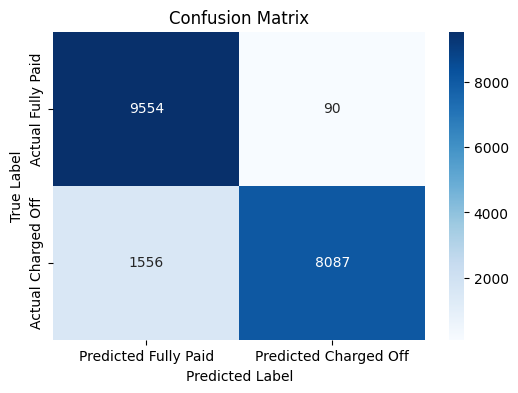


Classification Report:
              precision    recall  f1-score   support

  Fully Paid       0.86      0.99      0.92      9644
 Charged Off       0.99      0.84      0.91      9643

    accuracy                           0.91     19287
   macro avg       0.92      0.91      0.91     19287
weighted avg       0.92      0.91      0.91     19287



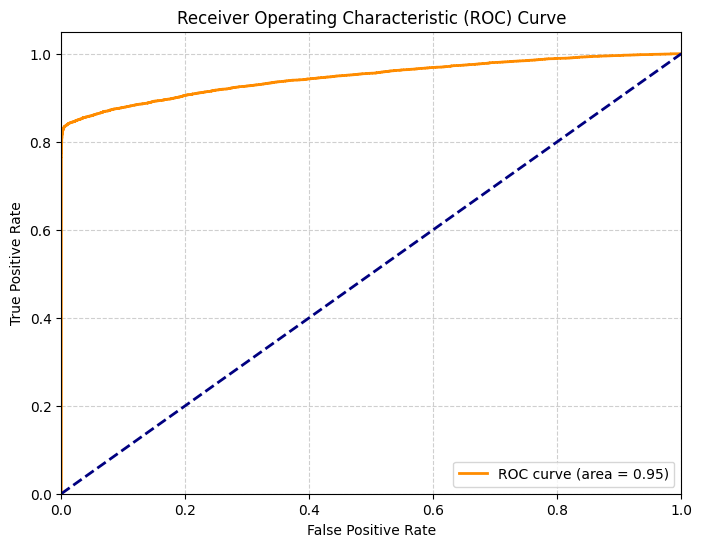

ROC-AUC Score: 0.95

Top 10 Most Influential Variables (sorted by absolute coefficient):


,Feature,Coefficient,Absolute_Coefficient
108,Sub_Grade_G4,-5.142578,5.142578
105,Sub_Grade_G1,-4.736816,4.736816
106,Sub_Grade_G2,-4.560583,4.560583
101,Sub_Grade_F2,-4.558241,4.558241
102,Sub_Grade_F3,-4.528585,4.528585
103,Sub_Grade_F4,-4.486395,4.486395
98,Sub_Grade_E4,-4.386944,4.386944
100,Sub_Grade_F1,-4.381039,4.381039
97,Sub_Grade_E3,-4.314747,4.314747
99,Sub_Grade_E5,-4.254638,4.254638



#### Business Interpretation of Top Variables: ####


In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming X_resampled and y_resampled_encoded are available from previous steps.
# Filter for binary classification: 'Fully Paid' (0) and 'Charged Off' (1)
# Exclude 'Current' (2) loans for this specific risk classification task.
binary_mask = (y_resampled_encoded == 0) | (y_resampled_encoded == 1)
X_binary = X_resampled[binary_mask]
y_binary = y_resampled_encoded[binary_mask]

print(f"Binary target class distribution: {y_binary.value_counts()}")

# 1. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary)

print(f"\nShape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}")

# 2. Logistic Regression model
# Using 'liblinear' solver for better convergence with L1/L2 regularization.
# Set max_iter for convergence.
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Train the model
log_reg_model.fit(X_train, y_train)

print("\nLogistic Regression Model Trained Successfully.")

# 3. Prediction
y_pred = log_reg_model.predict(X_test)
y_prob = log_reg_model.predict_proba(X_test)[:, 1] # Probability of the positive class (Charged Off = 1)

# 4. Evaluation

print("\n### Model Evaluation ###")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fully Paid', 'Predicted Charged Off'],
            yticklabels=['Actual Fully Paid', 'Actual Charged Off'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Accuracy, Precision, Recall, F1 Score
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fully Paid', 'Charged Off']))

# ROC Curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.2f}")


# Get coefficients and feature names
coefficients = log_reg_model.coef_[0]
feature_names = X_train.columns

# Create a DataFrame for better visualization
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
feature_importance['Absolute_Coefficient'] = np.abs(coefficients)

# Sort by absolute coefficient to see most influential variables
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

print("\nTop 10 Most Influential Variables (sorted by absolute coefficient):")
display(feature_importance.head(10))

# Business interpretation of top variables
print("\n#### Business Interpretation of Top Variables: ####")
for index, row in feature_importance.head(5).iterrows(): # Top 5 for detailed interpretation
    feature = row['Feature']
    coefficient = row['Coefficient']



Decision Tree

Binary target class distribution: Loan_Status
0    32145
1    32145
Name: count, dtype: int64

Shape of X_train_dt: (45003, 112), y_train_dt: (45003,)
Shape of X_test_dt: (19287, 112), y_test_dt: (19287,)

Decision Tree Classifier Trained Successfully.


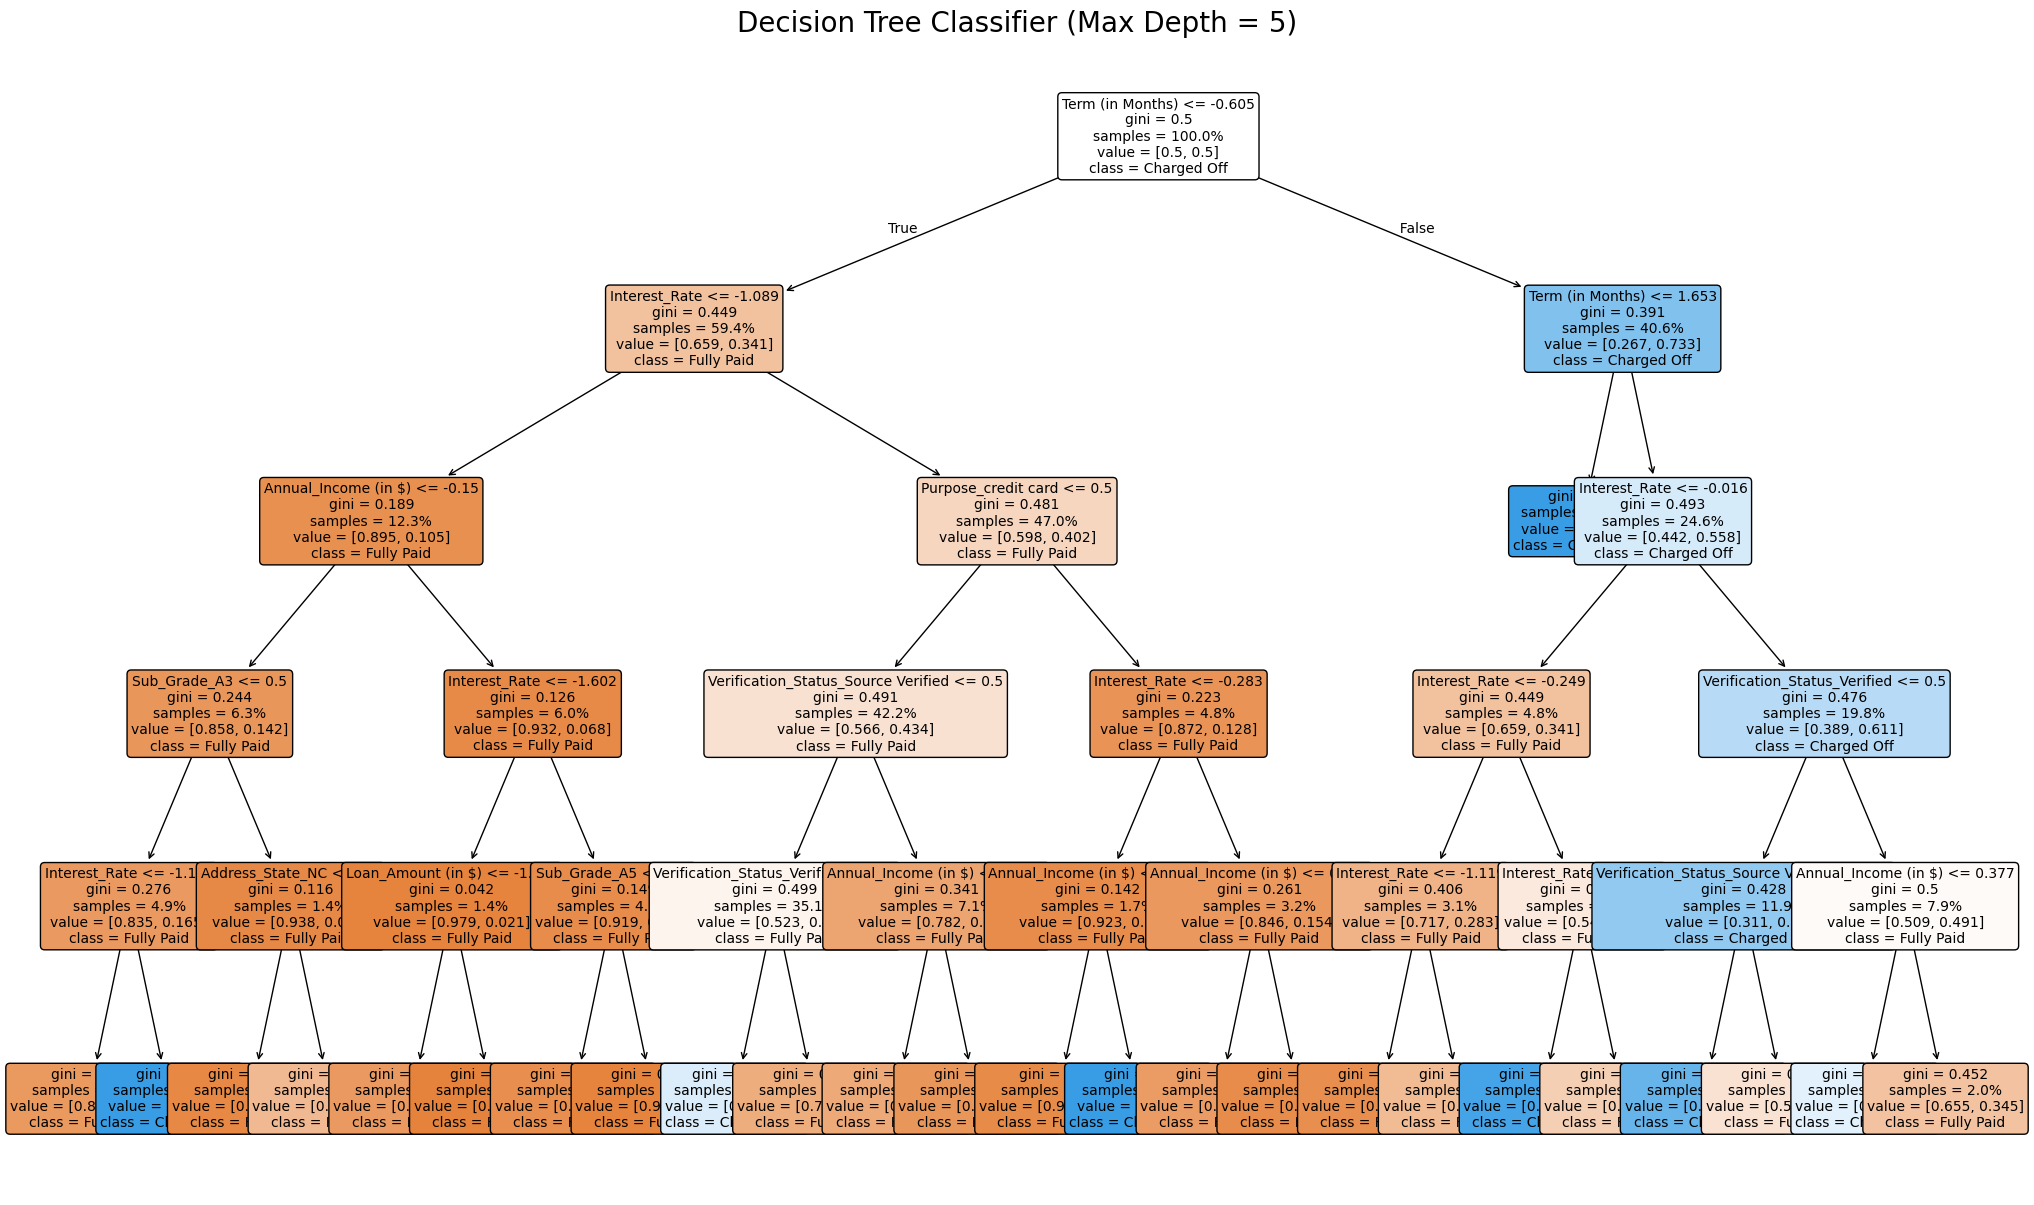


### Feature Importance for Decision Tree ###


,Feature,Importance
1,Term (in Months),0.629838
4,Interest_Rate,0.142590
110,Verification_Status_Source Verified,0.085856
111,Verification_Status_Verified,0.083757
64,Purpose_credit card,0.045569
2,Annual_Income (in $),0.010401
77,Sub_Grade_A3,0.001311
79,Sub_Grade_A5,0.000413
36,Address_State_NC,0.000200
5,Loan_Amount (in $),0.000065



### Model Evaluation (Decision Tree) ###

Confusion Matrix:


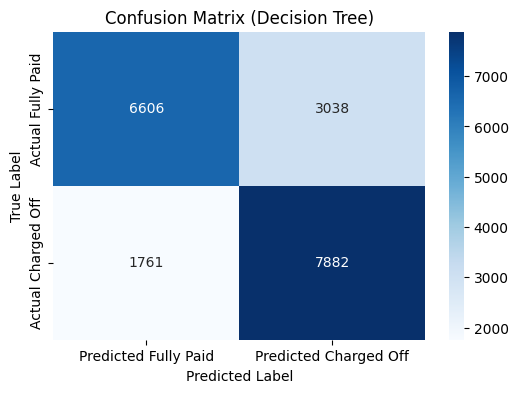


Classification Report:
              precision    recall  f1-score   support

  Fully Paid       0.79      0.68      0.73      9644
 Charged Off       0.72      0.82      0.77      9643

    accuracy                           0.75     19287
   macro avg       0.76      0.75      0.75     19287
weighted avg       0.76      0.75      0.75     19287



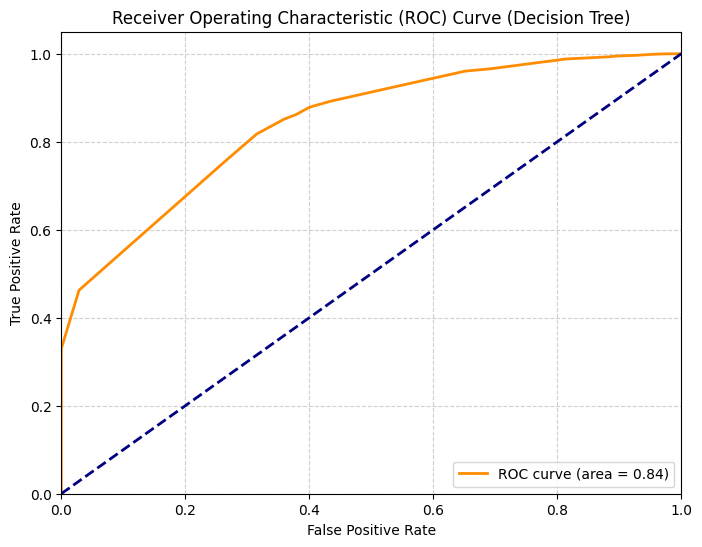

ROC-AUC Score: 0.84


In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming X_binary and y_binary are available from previous steps (binary classification for 'Fully Paid' and 'Charged Off')

print(f"Binary target class distribution: {y_binary.value_counts()}")

# 1. Train-test split
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary)

print(f"\nShape of X_train_dt: {X_train_dt.shape}, y_train_dt: {y_train_dt.shape}")
print(f"Shape of X_test_dt: {X_test_dt.shape}, y_test_dt: {y_test_dt.shape}")

# Decision Tree Classifier
# Setting max_depth to control complexity and prevent overfitting for visualization
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model
dt_classifier.fit(X_train_dt, y_train_dt)

print("\nDecision Tree Classifier Trained Successfully.")

# 2. Tree Visualization
plt.figure(figsize=(25, 15))
plot_tree(dt_classifier,
          feature_names=X_train_dt.columns.tolist(),
          class_names=['Fully Paid', 'Charged Off'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True)
plt.title('Decision Tree Classifier (Max Depth = 5)', fontsize=20)
plt.show()

# 3. Feature Importance
feature_importance_dt = pd.DataFrame({'Feature': X_train_dt.columns, 'Importance': dt_classifier.feature_importances_})
feature_importance_dt = feature_importance_dt.sort_values(by='Importance', ascending=False)

print("\n### Feature Importance for Decision Tree ###")
display(feature_importance_dt.head(10))

# Prediction
y_pred_dt = dt_classifier.predict(X_test_dt)
y_prob_dt = dt_classifier.predict_proba(X_test_dt)[:, 1] # Probability of the positive class (Charged Off = 1)

# Evaluation
print("\n### Model Evaluation (Decision Tree) ###")

# Confusion Matrix
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)
print("\nConfusion Matrix:")
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fully Paid', 'Predicted Charged Off'],
            yticklabels=['Actual Fully Paid', 'Actual Charged Off'])
plt.title('Confusion Matrix (Decision Tree)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Accuracy, Precision, Recall, F1 Score
print("\nClassification Report:")
print(classification_report(y_test_dt, y_pred_dt, target_names=['Fully Paid', 'Charged Off']))

# ROC Curve and ROC-AUC
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test_dt, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Decision Tree)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"ROC-AUC Score: {roc_auc_dt:.2f}")


Random Forest

Binary target class distribution in training set: Loan_Status
1    22502
0    22501
Name: count, dtype: int64
Binary target class distribution in test set: Loan_Status
0    9644
1    9643
Name: count, dtype: int64

Random Forest Classifier Trained Successfully.

### Model Evaluation (Random Forest) ###

Confusion Matrix:


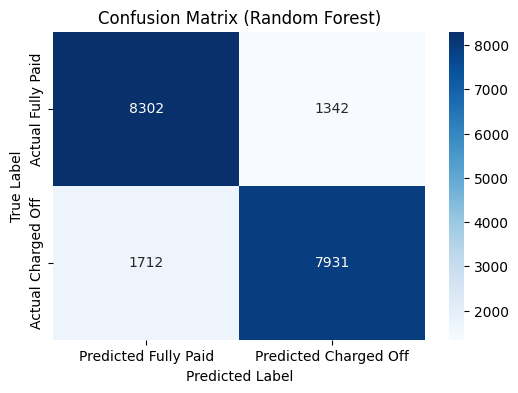


Classification Report:
              precision    recall  f1-score   support

  Fully Paid       0.83      0.86      0.84      9644
 Charged Off       0.86      0.82      0.84      9643

    accuracy                           0.84     19287
   macro avg       0.84      0.84      0.84     19287
weighted avg       0.84      0.84      0.84     19287



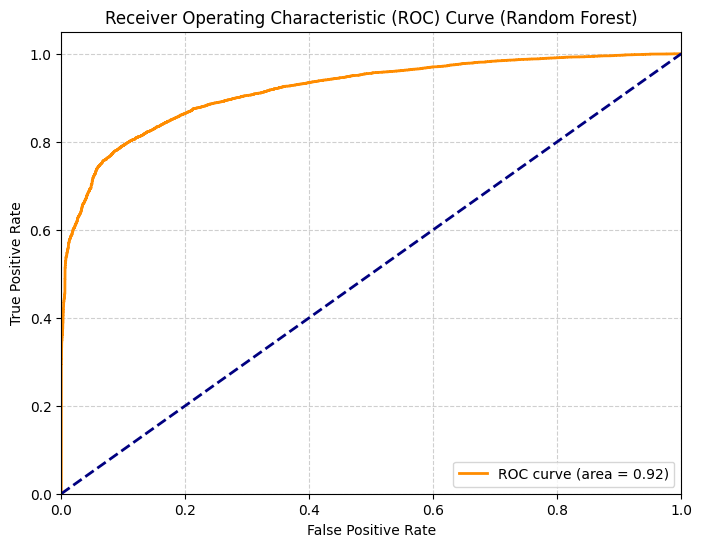

ROC-AUC Score: 0.92


In [41]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming X_train, X_test, y_train, y_test are available from previous steps (binary classification, preprocessed, and split)

print(f"Binary target class distribution in training set: {y_train.value_counts()}")
print(f"Binary target class distribution in test set: {y_test.value_counts()}")

# 1. Model Training: Random Forest Classifier
# Using a reasonable number of estimators and controlling depth to balance performance and overfitting
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores

# Train the model
rf_classifier.fit(X_train, y_train)

print("\nRandom Forest Classifier Trained Successfully.")

# Prediction
y_pred_rf = rf_classifier.predict(X_test)
y_prob_rf = rf_classifier.predict_proba(X_test)[:, 1] # Probability of the positive class (Charged Off = 1)

# 3. Performance Evaluation
print("\n### Model Evaluation (Random Forest) ###")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fully Paid', 'Predicted Charged Off'],
            yticklabels=['Actual Fully Paid', 'Actual Charged Off'])
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Accuracy, Precision, Recall, F1 Score
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Fully Paid', 'Charged Off']))

# ROC Curve and ROC-AUC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Random Forest)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"ROC-AUC Score: {roc_auc_rf:.2f}")


Model Comparison

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report

# Collected metrics from previous cells
metrics = {
    'Logistic Regression': {
        'Accuracy': 0.91,
        'Precision (Charged Off)': 0.99,
        'Recall (Charged Off)': 0.84,
        'F1 Score (Charged Off)': 0.91,
        'ROC-AUC': 0.95
    },
    'Decision Tree': {
        'Accuracy': 0.75,
        'Precision (Charged Off)': 0.72,
        'Recall (Charged Off)': 0.82,
        'F1 Score (Charged Off)': 0.77,
        'ROC-AUC': 0.84
    },
    'Random Forest': {
        'Accuracy': 0.84,
        'Precision (Charged Off)': 0.86,
        'Recall (Charged Off)': 0.82,
        'F1 Score (Charged Off)': 0.84,
        'ROC-AUC': 0.92
    }
}

# Create a DataFrame for comparison
comparison_df = pd.DataFrame(metrics).T

print("### Model Comparison Table ###")
display(comparison_df)


### Model Comparison Table ###


,Accuracy,Precision (Charged Off),Recall (Charged Off),F1 Score (Charged Off),ROC-AUC
Logistic Regression,0.91,0.99,0.84,0.91,0.95
Decision Tree,0.75,0.72,0.82,0.77,0.84
Random Forest,0.84,0.86,0.82,0.84,0.92
